In [126]:
## Imports and global configuration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, confusion_matrix
import re
from pathlib import Path
from urllib.parse import urlparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
from sklearn.pipeline import make_pipeline

In [127]:
## Helper functions for cleaning and visualization
def normalize_user_column(df):
   
    df.columns = [c.strip().lower() for c in df.columns]

    # Standardize user and user_id
    if 'user' in df.columns and 'user_id' not in df.columns:
        df.rename(columns={'user': 'user_id'}, inplace=True) 

    if 'user_id' in df.columns:
        df['user_id'] = df['user_id'].astype(str).str.strip().str.upper()

    # Converting date to timestamp
    if 'date' in df.columns:
        df['ts'] = pd.to_datetime(df['date'], errors='coerce')

    return df


def drop_nulls(df, key_cols):
    for col in key_cols:
        if col in df.columns:
            null_count = df[col].isnull().sum()
            print(f"{col}: {null_count} null(s) removed")
            
    df = df.dropna(subset=[col for col in key_cols if col in df.columns])
    return df


def plot_feature_heatmap(df, title, max_features=100):
  
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    selected_cols = numeric_df.columns
    
    corr = numeric_df.corr()
    
    # Dynamically size the figure based on number of features
    n_feat = len(selected_cols)
    fig_size = max(8, min(0.4 * n_feat + 4, 20))
    plt.figure(figsize=(fig_size, fig_size))
    
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        square=True,
        cbar=True,
        xticklabels=True,
        yticklabels=True
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


def drop_features(df, features_to_drop):

    cols_present = [col for col in features_to_drop if col in df.columns]

    cleaned_df = df.drop(columns=cols_present)

    print(f"Dropping {len(cols_present)} column(s): {cols_present}")
    print(f"Remaining columns: {cleaned_df.shape[1]}")

    return cleaned_df

ref 1  - Used Chatgpt to write this section of code for dynamically size the figure based on number of features
 "   n_feat = len(selected_cols)
    fig_size = max(8, min(0.4 * n_feat + 4, 20))
    plt.figure(figsize=(fig_size, fig_size)) " 

In [128]:

activity_files = ['logon','psychometric','http','file','email','device']
dfs = {}

#Psychometric Data
psych = pd.read_csv("psychometric.csv") 
print ("\n The initial psychometric data size")

psych = normalize_user_column(psych)

keep_cols = [c for c in ['user_id','employee_name','o','c','e','a','n'] if c in psych.columns] # OCEAN - Openness, Conscientiousness, Extraversion, Agreeableness, and Neuroticism
psych = psych[keep_cols].drop_duplicates(subset='user_id').reset_index(drop=True)
psych = drop_nulls(psych, key_cols=['user_id'])
print("Psychometric dataset shape:", psych.shape)
print(psych.head(3))


#Logon Data
logon = pd.read_csv("logon.csv")
logon = normalize_user_column(logon)
logon = logon[['user_id','pc','activity','ts']].drop_duplicates().reset_index(drop=True)

logon = drop_nulls(logon, key_cols=['user_id','ts'])
print("\nLogon dataset shape:", logon.shape)
print(logon.head(3))


#Device Data
device = pd.read_csv("device.csv")
device = normalize_user_column(device)
device = device[['user_id','pc','activity','ts']].drop_duplicates().reset_index(drop=True)

device = drop_nulls(device, key_cols=['user_id','ts'])
print("\nDevice dataset shape:", device.shape)
print(device.head(3))
#strip file_tree

#HTTP Data
http = pd.read_csv("http.csv")
http = normalize_user_column(http)
http = http[['user_id','pc','url','ts','content']].drop_duplicates().reset_index(drop=True)

http = drop_nulls(http, key_cols=['user_id','ts'])
print("\nHTTP dataset shape:", http.shape)
print(http.head(3))


#File Data
files = pd.read_csv("file.csv")
files = normalize_user_column(files)
files = files[['user_id','pc','filename','ts','content']].drop_duplicates().reset_index(drop=True)

files = drop_nulls(files, key_cols=['user_id','ts'])
print("\nFile dataset shape:", files.shape)
print(files.head(3))


#Email Data
email = pd.read_csv("email.csv")
email = normalize_user_column(email)
email_cols = [c for c in ['user_id','pc','to','cc','bcc','from','size','attachments','content','ts'] if c in email.columns]
email = email[email_cols].drop_duplicates().reset_index(drop=True)

email = drop_nulls(email, key_cols=['user_id','ts'])
print("\nEmail dataset shape:", email.shape)
print(email.head(3))


 The initial psychometric data size
user_id: 0 null(s) removed
Psychometric dataset shape: (2000, 7)
   user_id             employee_name   o   c   e   a   n
0  MMK1532        Maisie Maggy Kline  17  17  16  22  28
1  NTB0710         Nicole Tanya Burt  46  37  32  22  21
2  MTD0971  Madeline Tatum Donaldson  22  38  17  39  40
user_id: 0 null(s) removed
ts: 0 null(s) removed

Logon dataset shape: (1810070, 4)
   user_id       pc activity                  ts
0  JBI1134  PC-0168    Logon 2010-01-02 02:24:51
1  JBI1134  PC-0168   Logoff 2010-01-02 02:38:28
2  JBI1134  PC-2320    Logon 2010-01-02 04:55:52
user_id: 0 null(s) removed
ts: 0 null(s) removed

Device dataset shape: (836934, 4)
   user_id       pc    activity                  ts
0  HRE1950  PC-8025     Connect 2010-01-02 07:27:19
1  EMR0269  PC-6370     Connect 2010-01-02 07:40:51
2  EMR0269  PC-6370  Disconnect 2010-01-02 07:45:00
user_id: 0 null(s) removed
ts: 0 null(s) removed

HTTP dataset shape: (58960449, 5)
   user_id    

In [129]:
## LDAP 

LDAP_path = Path.cwd() /"LDAP"
ldap_files = sorted([f for f in LDAP_path.glob('*.csv')])
print(f"Found {len(ldap_files)} monthly LDAP files")


all_ldap = []

for f in ldap_files:
    df = pd.read_csv(f)
    df = normalize_user_column(df)
    
    keep_cols = [c for c in ['user_id', 'employee_name', 'supervisor', 'role'] if c in df.columns]
    df = df[keep_cols]

    # Extracting month from filename (2009-12)
    month_match = re.search(r'(\d{4}-\d{2})', f.name)
    if month_match:
        df['month'] = month_match.group(1)

    all_ldap.append(df)


ldap_master = pd.concat(all_ldap, ignore_index=True)

ldap_master = ldap_master.drop_duplicates(subset=['user_id', 'month']).reset_index(drop=True)

print("Before supervisor conversion:", ldap_master.shape)
print(ldap_master.head(5))



# Converting supervisor names to supervisor user_ids

name_to_userid = (
    ldap_master.drop_duplicates(subset=['employee_name'])
               .set_index('employee_name')['user_id']
               .to_dict()
)

if 'supervisor' in ldap_master.columns:
    ldap_master['supervisor'] = ldap_master['supervisor'].map(lambda x: name_to_userid.get(x, x))

print("\nAfter supervisor conversion:", ldap_master.shape)
print(ldap_master.head(5))


# Creating per-user monthly timeline 
months = sorted(ldap_master['month'].unique())
users = ldap_master['user_id'].unique()
user_timeline = pd.DataFrame({'user_id': users})

for m in months:
    month_df = ldap_master[ldap_master['month'] == m]
    sup_dict = month_df.set_index('user_id')['supervisor'].to_dict()

    # Fill with supervisor's user_id or resigned - this was done to avoid an extra set of feature set for each month if we split into separate datasets for active/resigned and supervisor's user ID - we imply that if useer is active will have a supervisor ID else will not 
    user_timeline[m] = user_timeline['user_id'].apply(lambda x: sup_dict.get(x, 'Resigned'))

print("\nUser timeline with supervisor user_id / 'Resigned' per month shape:", user_timeline.shape)
print(user_timeline.head(5))

Found 18 monthly LDAP files
Before supervisor conversion: (34087, 5)
   user_id             employee_name                  supervisor  \
0  MMK1532        Maisie Maggy Kline         Yvette Naomi Cortez   
1  NTB0710         Nicole Tanya Burt  Brennan Thaddeus Dominguez   
2  MTD0971  Madeline Tatum Donaldson         Todd Rajah Peterson   
3  NHB1529  Nicholas Hamish Browning         Yvette Naomi Cortez   
4  HBW0057           Hoyt Berk Wiley             Rina Adena Horn   

                      role    month  
0               Technician  2009-12  
1  SoftwareQualityEngineer  2009-12  
2       ElectricalEngineer  2009-12  
3               Technician  2009-12  
4           ProjectManager  2009-12  

After supervisor conversion: (34087, 5)
   user_id             employee_name supervisor                     role  \
0  MMK1532        Maisie Maggy Kline    YNC1336               Technician   
1  NTB0710         Nicole Tanya Burt    BTD0296  SoftwareQualityEngineer   
2  MTD0971  Madeline Tatu

In [130]:
# Feature extraction from device data
def build_device_features_from_clean(
    device_df,
    days_window=30,
):
  
    df = device_df.copy()
 
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    df = df.dropna(subset=["ts"])

    df["activity"] = df["activity"].astype(str).str.strip()
    df = df[df["activity"].str.lower().isin(["connect", "disconnect"])]

    if df.empty:
        empty_features = pd.DataFrame(
            columns=[
                "user_id",
                "usb_insert_count",
                "usb_remove_count",
                "usb_events_total",
                "usb_days_active",
                "usb_session_count",
                "usb_duration_mean_min",
                "usb_duration_max_min",
                "usb_duration_sum_min",
                "usb_after_hours_sessions",
                "usb_weekend_sessions",
                "usb_sessions_per_active_day",
                "usb_after_hours_session_ratio",
                "usb_weekend_session_ratio",
                "usb_peak_usage_hour",
                "usb_session_count_win_last30",
                "usb_session_days_active_win_last30",
                "usb_session_count_win_before30",
                "usb_session_days_active_win_before30",
                "usb_usage_rate_last30",
                "usb_usage_rate_before30",
                "usb_usage_rate_delta",
            ]
        )
        return empty_features, pd.DataFrame(columns=[])

    
    df["is_connect"] = df["activity"].str.lower() == "connect"
    df["is_disconnect"] = df["activity"].str.lower() == "disconnect"

    # eventcounts per user 
    event_counts = df.groupby("user_id").agg(
        usb_insert_count=("is_connect", "sum"),
        usb_remove_count=("is_disconnect", "sum"),
        usb_events_total=("activity", "count"),
        usb_days_active=("ts", lambda x: x.dt.date.nunique()),
    )

    # usb sessions
    df = df.sort_values(["user_id", "pc", "ts"])

    sessions = []
    for (user, pc), g in df.groupby(["user_id", "pc"], sort=False):
        open_start = None

        for _, row in g.iterrows():
            ts = row["ts"]
            act = row["activity"].lower()

            if act == "connect":
                if open_start is None:
                    open_start = ts
                else:
                    #ignore extra connects if already connected
                    continue

            elif act == "disconnect":
                if open_start is not None and ts >= open_start:
                    duration_min = (ts - open_start).total_seconds() / 60.0
                    sessions.append(
                        {
                            "user_id": user,
                            "pc": pc,
                            "usb_start": open_start,
                            "usb_end": ts,
                            "usb_duration_min": duration_min,
                        }
                    )
                    open_start = None
                else:
                    # ignore disconnects if already not connected 
                    continue

    device_session_df = pd.DataFrame(sessions)

    # If no valid sessions, just return event-level stuff
    if device_session_df.empty:
        features = event_counts.copy()
        features["usb_session_count"] = 0
        features["usb_duration_mean_min"] = 0.0
        features["usb_duration_max_min"] = 0.0
        features["usb_duration_sum_min"] = 0.0
        features["usb_after_hours_sessions"] = 0
        features["usb_weekend_sessions"] = 0
        features["usb_sessions_per_active_day"] = 0.0
        features["usb_after_hours_session_ratio"] = 0.0
        features["usb_weekend_session_ratio"] = 0.0
        features["usb_peak_usage_hour"] = 0.0
        features["usb_session_count_win_last30"] = 0
        features["usb_session_days_active_win_last30"] = 0
        features["usb_session_count_win_before30"] = 0
        features["usb_session_days_active_win_before30"] = 0
        features["usb_usage_rate_last30"] = 0.0
        features["usb_usage_rate_before30"] = 0.0
        features["usb_usage_rate_delta"] = 0.0

        return features.reset_index(), device_session_df

    # Session-level attributes 
    device_session_df["date_only"] = device_session_df["usb_start"].dt.date
    device_session_df["start_hour"] = (
        device_session_df["usb_start"].dt.hour
        + device_session_df["usb_start"].dt.minute / 60.0
    )
    device_session_df["end_hour"] = (
        device_session_df["usb_end"].dt.hour
        + device_session_df["usb_end"].dt.minute / 60.0
    )
    device_session_df["weekday"] = device_session_df["usb_start"].dt.weekday
    device_session_df["is_weekend"] = device_session_df["weekday"] >= 5

    # after-hours session outside of 8AM - 6PM 
    device_session_df["is_after_hours_session"] = (
        (device_session_df["start_hour"] < 8)
        | (device_session_df["start_hour"] >= 18)
        | (device_session_df["end_hour"] < 8)
        | (device_session_df["end_hour"] >= 18)
    )

    # Aggregate sessions per user
    session_agg = device_session_df.groupby("user_id").agg(
        usb_session_count=("usb_start", "count"),
        usb_session_days_active=("date_only", "nunique"),
        usb_duration_mean_min=("usb_duration_min", "mean"),
        usb_duration_std_min=("usb_duration_min", "std"),
        usb_duration_max_min=("usb_duration_min", "max"),
        usb_duration_sum_min=("usb_duration_min", "sum"),
        usb_after_hours_sessions=("is_after_hours_session", "sum"),
        usb_weekend_sessions=("is_weekend", "sum"),
    )

    session_agg["usb_sessions_per_active_day"] = (
        session_agg["usb_session_count"]
        / session_agg["usb_session_days_active"].replace(0, np.nan)
    )
    session_agg["usb_after_hours_session_ratio"] = (
        session_agg["usb_after_hours_sessions"]
        / session_agg["usb_session_count"].replace(0, np.nan)
    )
    session_agg["usb_weekend_session_ratio"] = (
        session_agg["usb_weekend_sessions"]
        / session_agg["usb_session_count"].replace(0, np.nan)
    )

    # Peak usage hour
    def peak_hour(group):
        counts = group["start_hour"].round().value_counts()
        if counts.empty:
            return 0.0
        return counts.idxmax()

    peak_hours = (
    device_session_df.groupby("user_id")["start_hour"]
    .apply(lambda s: s.round().value_counts().idxmax() if not s.empty else 0)
    .rename("usb_peak_usage_hour")#specifies time of the day  
    )

    # drift part 
    max_ts = device_session_df["usb_start"].max()
    cutoff = max_ts - pd.Timedelta(days=days_window)
    device_session_df["is_last_window"] = device_session_df["usb_start"] >= cutoff

    def agg_window(subset):
        if subset.empty:
            return pd.DataFrame(
                columns=[
                    "user_id",
                    "usb_session_count_win",
                    "usb_session_days_active_win",
                ]
            ).set_index("user_id")
        g = subset.groupby("user_id").agg(
            usb_session_count_win=("usb_start", "count"),
            usb_session_days_active_win=("date_only", "nunique"),
        )
        return g

    last = agg_window(
        device_session_df[device_session_df["is_last_window"]]
    ).add_suffix("_last30")
    before = agg_window(
        device_session_df[~device_session_df["is_last_window"]]
    ).add_suffix("_before30")

    # merging everything 
    features = event_counts.join(session_agg, how="outer").join(peak_hours, how="left")
    features = features.join(last, how="left").join(before, how="left").fillna(0)

    # usage rate 
    features["usb_usage_rate_last30"] = (
        features["usb_session_count_win_last30"]
        / features["usb_session_days_active_win_last30"].replace(0, np.nan)
    )
    features["usb_usage_rate_before30"] = (
        features["usb_session_count_win_before30"]
        / features["usb_session_days_active_win_before30"].replace(0, np.nan)
    )

    features["usb_usage_rate_delta"] = (
        features["usb_usage_rate_last30"].fillna(0)
        - features["usb_usage_rate_before30"].fillna(0)
    )

    features = features.fillna(0)

    return features.reset_index(), device_session_df

device_features, device_sessions = build_device_features_from_clean(device)

print(device_features.head())
print(device_features.describe())
print(device_features.shape)

   user_id  usb_insert_count  usb_remove_count  usb_events_total  \
0  AAB1302              3299              3285              6584   
1  AAB1762               366               362               728   
2  AAO1919               139               139               278   
3  AAW0952               135               135               270   
4  ABB0019              2835              2824              5659   

   usb_days_active  usb_session_count  usb_session_days_active  \
0              415               3285                      415   
1              239                362                      238   
2              117                139                      117   
3              111                135                      111   
4              356               2822                      356   

   usb_duration_mean_min  usb_duration_std_min  usb_duration_max_min  ...  \
0              18.075256             79.308810           3872.666667  ...   
1              65.831998            378.

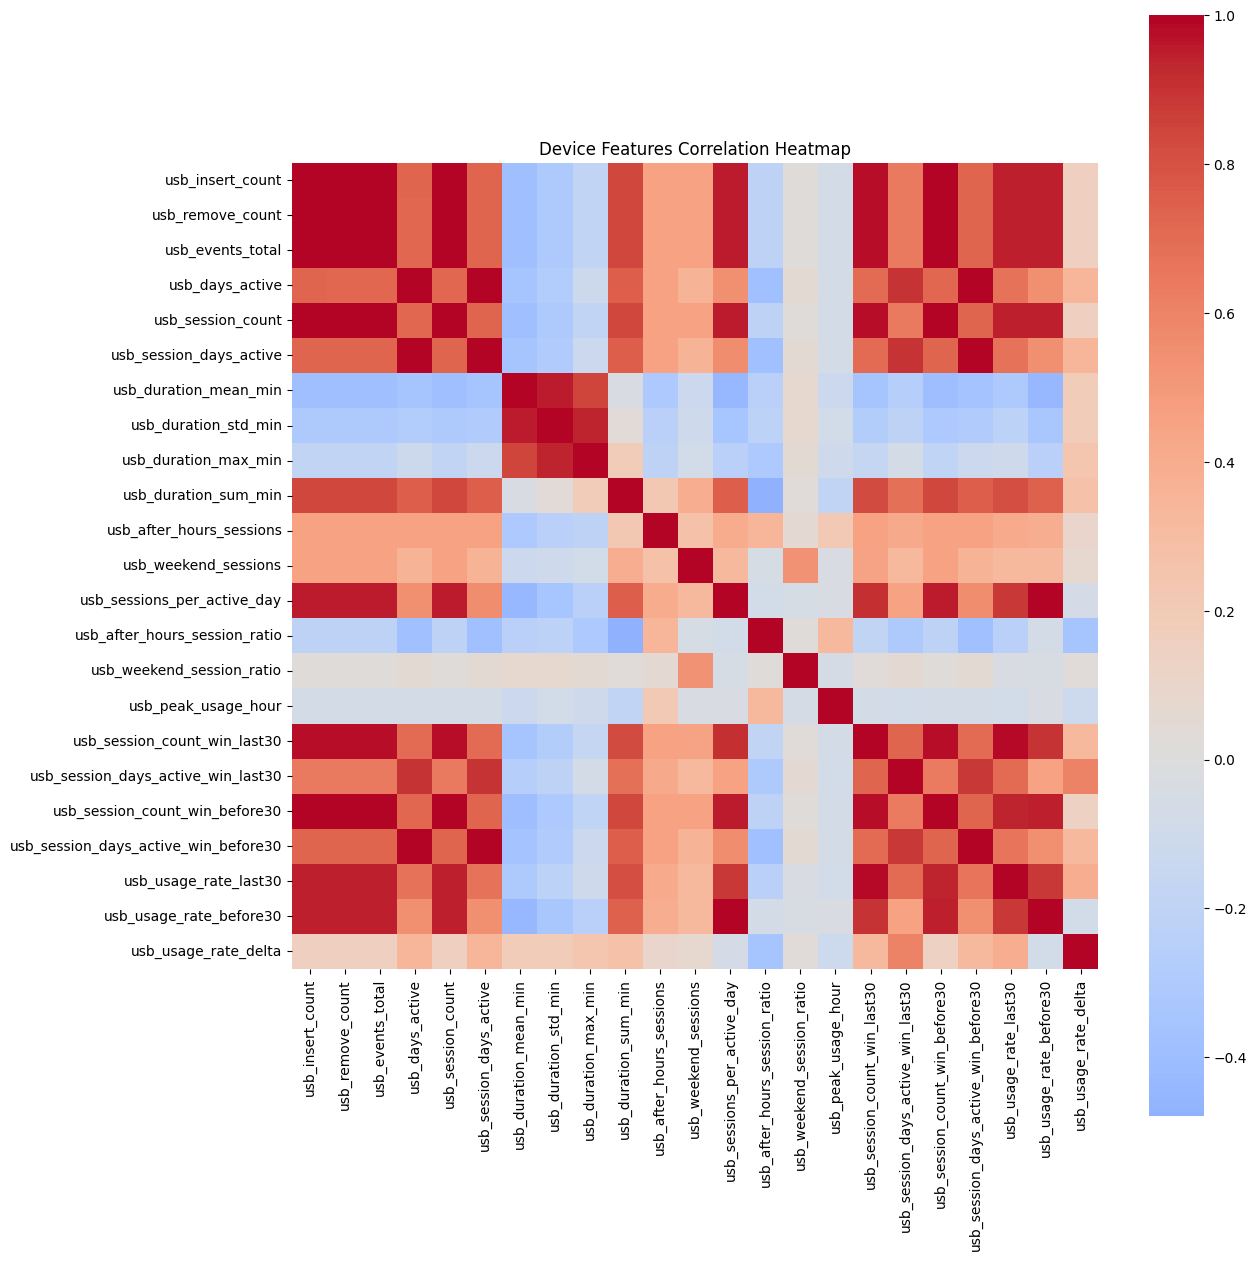

In [131]:
plot_feature_heatmap(
    device_features,
    title="Device Features Correlation Heatmap")
    

In next cell, we dropped these columns because they were mathematically redundant derivatives—like duration_sum simply being mean × count—which introduced noise rather than new behavioral signals for our insider detection model. We also found that the split-window metrics (e.g., win_last30) were statistically identical to the total lifetime aggregates we already created, causing severe multicollinearity that would destabilize the weights in our Logistic Regression model.

In [132]:
## Drop redundant or highly correlated device features
# removing these features based on high correlation with other values 
device_drop_cols = [
    'usb_session_count_win_last30',
    'usb_session_days_active_win_last30',
    'usb_session_count_win_before30',
    'usb_session_days_active_win_before30',
    'usb_duration_std_min',
    'usb_duration_sum_min',
    'usb_sessions_per_active_day',
    'usb_days_active',
    'usb_peak_usage_hour',
    'usb_usage_rate_before30'
    'usb_remove_count',
   
]

device_features=drop_features(device_features, device_drop_cols)
print(device_features.head())
print(device_features.shape)

Dropping 9 column(s): ['usb_session_count_win_last30', 'usb_session_days_active_win_last30', 'usb_session_count_win_before30', 'usb_session_days_active_win_before30', 'usb_duration_std_min', 'usb_duration_sum_min', 'usb_sessions_per_active_day', 'usb_days_active', 'usb_peak_usage_hour']
Remaining columns: 15
   user_id  usb_insert_count  usb_remove_count  usb_events_total  \
0  AAB1302              3299              3285              6584   
1  AAB1762               366               362               728   
2  AAO1919               139               139               278   
3  AAW0952               135               135               270   
4  ABB0019              2835              2824              5659   

   usb_session_count  usb_session_days_active  usb_duration_mean_min  \
0               3285                      415              18.075256   
1                362                      238              65.831998   
2                139                      117              48.675

In [133]:
## Build file-level feature table
def build_file_features(files_df, ts_col="ts", days_window=30):
    df = files_df.copy()

    # --- 1. Ensure timestamp column exists and is parsed ---
    if ts_col not in df.columns:
        raise KeyError(
            f"Timestamp column '{ts_col}' not found in files_df. "
            f"Available columns: {df.columns.tolist()}"
        )

    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=["user_id", ts_col])

    if df.empty:
        return pd.DataFrame(columns=["user_id"]), df

    df = df.rename(columns={ts_col: "ts"})

    df["extension"] = (
        df["filename"]
        .astype(str)
        .str.lower()
        .str.extract(r"\.([a-z0-9]+)$")
    )
    df["keywords"] = (
        df["content"]
        .astype(str)
        .str.split()
        .apply(lambda x: x[1:] if len(x) > 1 else [])
    )

    # defining rule based flags using keywords
    keyword_groups = {
        "cloud_storage": ["dropbox", "gdrive", "onedrive", "box.com"],
        "wikileaks": ["wikileaks", "leak","julian assange", "whistleblower", "securedrop", "tor project", "tails os", "intercept", "submission", "encrypted upload", "insurance file", "wlup", "onion"],
        "job_search": ["resume", "jobs", "career", "hiring", "interview"],
        "keylogger": ["keylogger", "spyware","malware","install", "setup", "klog", "logger", ".exe", "executable", "hack", "crack"],
        "sensitive_keywords": ["confidential", "secret", "classified", "financial","password", "passwords", "login", "credentials", "budget", "forecast", "strategy", "presentation", "salary", "payroll", "ssn", "social security", "tax", "legal"],
    }

    def contains_group(keywords, group_keys): # keywords is a Python list of tokens whereas group_keys is a list of strings
        kws_set = set(k.lower() for k in keywords)
        for g in group_keys:
            if g.lower() in kws_set:
                return 1
        return 0

    for group_name, keys in keyword_groups.items():
        df[group_name] = df["keywords"].apply(lambda words: contains_group(words, keys))


    sensitive_exts = ["pdf", "doc", "docx", "xls", "xlsx", "ppt", "pptx"]
    df["is_sensitive_ext"] = df["extension"].isin(sensitive_exts).astype(int)

    #all time stats
    base = df.groupby("user_id").agg(
        file_copy_count=("filename", "count"),
        unique_files_accessed=("filename", "nunique"),
        unique_file_extensions=("extension", "nunique"),
        sensitive_file_access_count=("is_sensitive_ext", "sum"),
        cloud_storage_files=("cloud_storage", "sum"),
        wikileaks_files=("wikileaks", "sum"),
        job_search_files=("job_search", "sum"),
        keylogger_files=("keylogger", "sum"),
        sensitive_keyword_files=("sensitive_keywords", "sum"),
    )

    # last vs beore stats
    max_ts = df["ts"].max()
    cutoff = max_ts - pd.Timedelta(days=days_window)
    df["is_last_window"] = df["ts"] >= cutoff

    # Last 30 days stats
    last = df[df["is_last_window"]].groupby("user_id").agg(
        file_copy_last30=("filename", "count"),
        sensitive_last30=("is_sensitive_ext", "sum"),
        dropbox_last30=("cloud_storage", "sum"),
    )
    #total before 30
    before = df[~df["is_last_window"]].groupby("user_id").agg(
        file_copy_before30=("filename", "count"),
        sensitive_before30=("is_sensitive_ext", "sum"),
        dropbox_before30=("cloud_storage", "sum"),
    )

    features = (
        base.join(last, how="left")
            .join(before, how="left")
            .fillna(0)
    )

    # baseline
    df["year_month"] = df["ts"].dt.to_period("M")

    # Only consider historical months strictly before cutoff
    historical = df[df["ts"] < cutoff]

    if not historical.empty:
        monthly = historical.groupby(["user_id", "year_month"]).agg(
            monthly_file_copy=("filename", "count"),
            monthly_sensitive=("is_sensitive_ext", "sum"),
            monthly_dropbox=("cloud_storage", "sum"),
        ).reset_index()

        baselines = monthly.groupby("user_id").agg(
            file_copy_baseline=("monthly_file_copy", "mean"),
            sensitive_baseline=("monthly_sensitive", "mean"),
            dropbox_baseline=("monthly_dropbox", "mean"),
        )
    else:
        baselines = pd.DataFrame(
            0,
            index=features.index,
            columns=["file_copy_baseline", "sensitive_baseline", "dropbox_baseline"],
        )

    # Align baselines on user_id
    features = features.join(baselines, how="left").fillna(0)

    # recent vs baseline - delta calculations
    features["file_copy_delta"] = (
        features["file_copy_last30"] - features["file_copy_baseline"]
    )
    features["sensitive_file_delta"] = (
        features["sensitive_last30"] - features["sensitive_baseline"]
    )
    features["dropbox_delta"] = (
        features["dropbox_last30"] - features["dropbox_baseline"]
    )

    features = features.reset_index()

    return features, df
file_features, processed_file_df = build_file_features(files)
print(file_features.head())
print(file_features.describe())

   user_id  file_copy_count  unique_files_accessed  unique_file_extensions  \
0  AAB1302              421                     23                       5   
1  AAB1762             1834                     54                       4   
2  AAO1919              272                     41                       6   
3  AAW0952              247                     34                       5   
4  ABB0019             8369                     38                       6   

   sensitive_file_access_count  cloud_storage_files  wikileaks_files  \
0                          273                    0                0   
1                         1537                    0                0   
2                          237                    0                2   
3                          194                    0                0   
4                         6808                    0               11   

   job_search_files  keylogger_files  sensitive_keyword_files  ...  \
0                26         

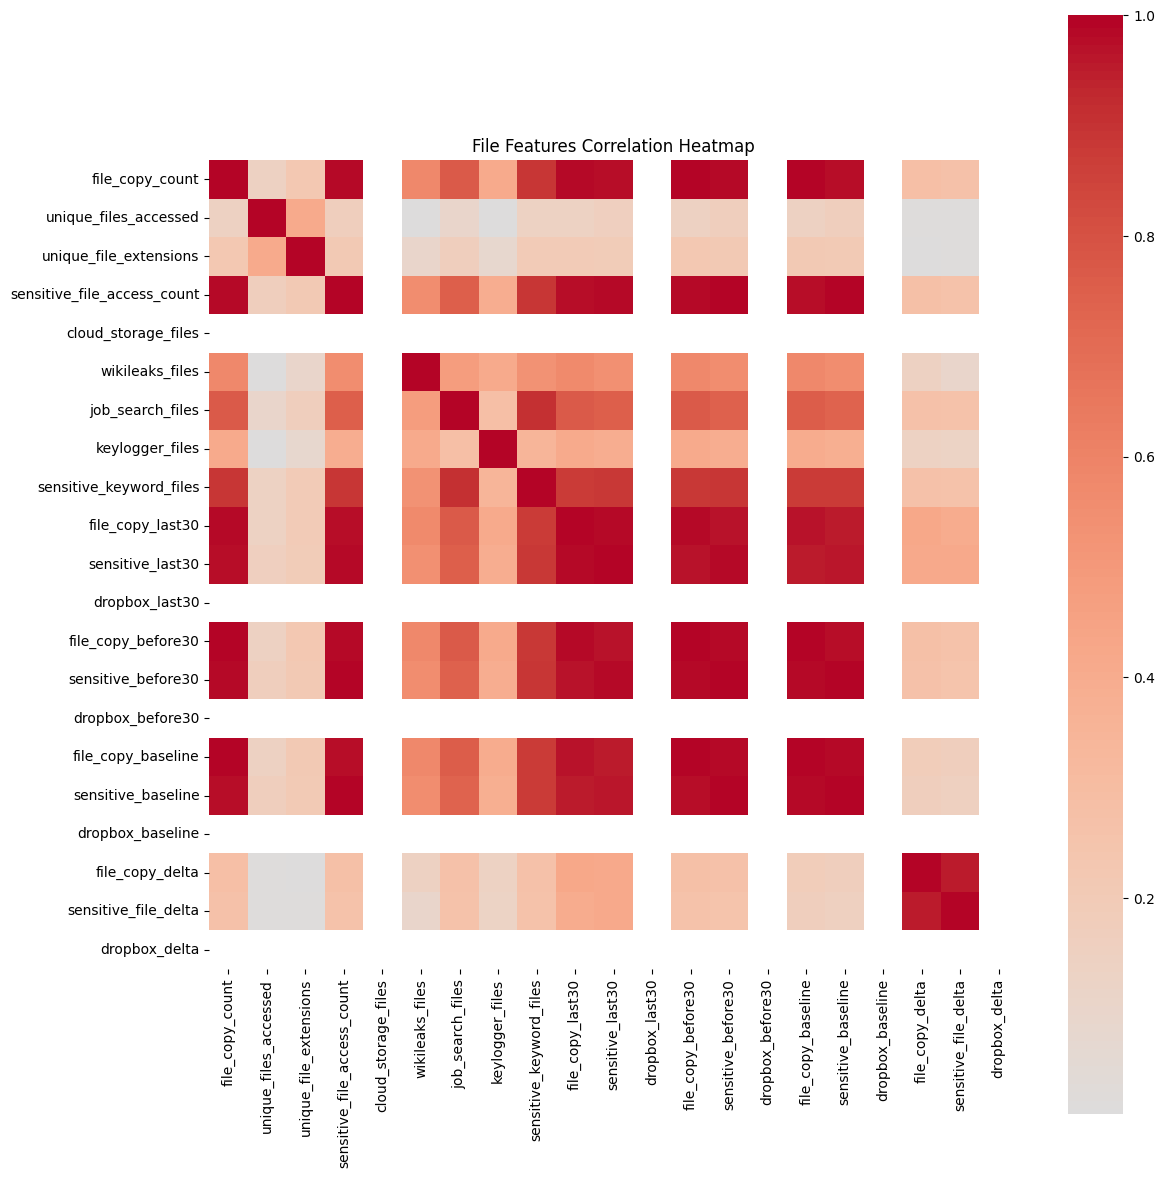

In [134]:

# File features
plot_feature_heatmap(
    file_features,
    title="File Features Correlation Heatmap")

We dropped these columns because they were redundant temporal splits (e.g., _before30 and _baseline) that duplicated the information already captured in our total lifetime counts, leading to high multicollinearity. Additionally, we removed unique_file_extensions and unique_files_accessed as they were strongly correlated with overall activity volume and did not provide unique behavioral signals for insider detection. Even though in keyword search some features like cloud_storage_files and Dropbox_last30 is 0 we have kept it as a genaral keyword search which would be open to any new data added in future. 

In [135]:
## Drop based on correl 
file_drop_cols = [
    'file_copy_count',
    'file_copy_before30',
    'file_copy_baseline',
    'sensitive_file_access_count',
    'sensitive_before30',
    'sensitive_baseline',
    'cloud_storage_files',
    'dropbox_before30',
    'dropbox_baseline',
    "unique_file_extensions",
    "unique_files_accessed"
]
file_features= drop_features(file_features, file_drop_cols)
print(file_features.describe())

Dropping 11 column(s): ['file_copy_count', 'file_copy_before30', 'file_copy_baseline', 'sensitive_file_access_count', 'sensitive_before30', 'sensitive_baseline', 'cloud_storage_files', 'dropbox_before30', 'dropbox_baseline', 'unique_file_extensions', 'unique_files_accessed']
Remaining columns: 11
       wikileaks_files  job_search_files  keylogger_files  \
count       473.000000        473.000000       473.000000   
mean          4.211416         81.021142         2.334038   
std           9.371438        148.124402         6.387425   
min           0.000000          0.000000         0.000000   
25%           0.000000          8.000000         0.000000   
50%           0.000000         28.000000         0.000000   
75%           4.000000         89.000000         2.000000   
max          91.000000       1405.000000        70.000000   

       sensitive_keyword_files  file_copy_last30  sensitive_last30  \
count               473.000000        473.000000        473.000000   
mean        

In [136]:
## HTTP feature extraction 
def build_http_features(http_df, ts_col="ts", days_window=30):
    df = http_df.copy()

    if ts_col not in df.columns:
        raise KeyError(
            f"Timestamp column '{ts_col}' not found in http_df. "
            f"Available columns: {df.columns.tolist()}"
        )

    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=["user_id", ts_col])

    if df.empty:
        return pd.DataFrame(columns=["user_id"]), df

    df = df.rename(columns={ts_col: "ts"})

    
    def extract_domain(u):
        try:
            parsed = urlparse(str(u))
            if parsed.netloc:
                return parsed.netloc.lower()
            return str(u).split('/')[0].lower()
        except Exception:
            return ""

    df["domain"] = df["url"].astype(str).apply(extract_domain)


    df["url_str"] = df["url"].astype(str).str.lower()
    df["content_str"] = df["content"].astype(str).str.lower()

    # defining rule based flags using keywords
    job_terms       = ["job", "jobs", "career", "hiring", "interview", "resume","monster.com", "careerbuilder", "indeed", "glassdoor", "simplyhired", "linkedin", "salary"]
    cloud_terms     = ["dropbox", "gdrive", "google drive", "onedrive", "skydrive", "box.com"]
    wikileaks_terms = ["wikileaks", "leak","secure drop"]
    keylogger_terms = ["keylogger", "spyware", "keystroke logger", "crack", "hack",  "freeware", "winspy", 
    "spector", "refog", "klog"]

    def contains_any_text(text, terms):
        text = text.lower()
        return any(t in text for t in terms)

    # boolean flags
    df["is_job_search"] = df.apply(
        lambda row: contains_any_text(row["url_str"], job_terms) or
                    contains_any_text(row["content_str"], job_terms),
        axis=1
    )

    df["is_cloud"] = df.apply(
        lambda row: contains_any_text(row["url_str"], cloud_terms) or
                    contains_any_text(row["content_str"], cloud_terms),
        axis=1
    )

    df["is_wikileaks"] = df.apply(
        lambda row: contains_any_text(row["url_str"], wikileaks_terms) or
                    contains_any_text(row["content_str"], wikileaks_terms),
        axis=1
    )

    df["is_keylogger"] = df.apply(
        lambda row: contains_any_text(row["url_str"], keylogger_terms) or
                    contains_any_text(row["content_str"], keylogger_terms),
        axis=1
    )

    # all table
    base = df.groupby("user_id").agg(
        total_http_requests=("url", "count"),
        unique_domains=("domain", "nunique"),
        job_search_visits=("is_job_search", "sum"),
        cloud_storage_visits=("is_cloud", "sum"),
        wikileaks_visits=("is_wikileaks", "sum"),
        keylogger_page_visits=("is_keylogger", "sum"),
    )

    
    max_ts = df["ts"].max()
    cutoff = max_ts - pd.Timedelta(days=days_window)
    df["is_last_window"] = df["ts"] >= cutoff

    # Last 30 days
    last = df[df["is_last_window"]].groupby("user_id").agg(
        http_requests_last30=("url", "count"),
        job_search_last30=("is_job_search", "sum"),
        cloud_last30=("is_cloud", "sum"),
        wikileaks_last30=("is_wikileaks", "sum"),
    )

    # before 30 days 
    before = df[~df["is_last_window"]].groupby("user_id").agg(
        http_requests_before30=("url", "count"),
        job_search_before30=("is_job_search", "sum"),
        cloud_before30=("is_cloud", "sum"),
        wikileaks_before30=("is_wikileaks", "sum"),
    )

    features = (
        base.join(last, how="left")
            .join(before, how="left")
            .fillna(0)
    )

    # baselines 
    df["year_month"] = df["ts"].dt.to_period("M")
    historical = df[df["ts"] < cutoff]

    if not historical.empty:
        monthly = historical.groupby(["user_id", "year_month"]).agg(
            monthly_http_requests=("url", "count"),
            monthly_job_search=("is_job_search", "sum"),
            monthly_cloud=("is_cloud", "sum"),
            monthly_wikileaks=("is_wikileaks", "sum"),
        ).reset_index()

        baselines = monthly.groupby("user_id").agg(
            http_requests_baseline=("monthly_http_requests", "mean"),
            job_search_baseline=("monthly_job_search", "mean"),
            cloud_visits_baseline=("monthly_cloud", "mean"),
            wikileaks_baseline=("monthly_wikileaks", "mean"),
        )
    else:
        baselines = pd.DataFrame(
            0,
            index=features.index,
            columns=[
                "http_requests_baseline",
                "job_search_baseline",
                "cloud_visits_baseline",
                "wikileaks_baseline",
            ],
        )

    features = features.join(baselines, how="left").fillna(0)

    # delta calculations
    features["http_requests_delta"] = (
        features["http_requests_last30"] - features["http_requests_baseline"]
    )
    features["job_search_delta"] = (
        features["job_search_last30"] - features["job_search_baseline"]
    )
    features["cloud_visits_delta"] = (
        features["cloud_last30"] - features["cloud_visits_baseline"]
    )
    features["wikileaks_visits_delta"] = (
        features["wikileaks_last30"] - features["wikileaks_baseline"]
    )

    features = features.reset_index()

    return features, df
http_features, processed_http_df = build_http_features(http, ts_col="ts", days_window=30)

print(http_features.describe())

       total_http_requests  unique_domains  job_search_visits  \
count          2000.000000     2000.000000        2000.000000   
mean          29480.224500      154.500000        2673.305000   
std           21342.066084       52.102882        2453.788781   
min             240.000000       17.000000          10.000000   
25%           10341.000000      115.000000         673.000000   
50%           33820.000000      152.000000        1956.500000   
75%           40688.000000      192.000000        3933.000000   
max          169100.000000      320.000000       19919.000000   

       cloud_storage_visits  wikileaks_visits  keylogger_page_visits  \
count           2000.000000       2000.000000             2000.00000   
mean             416.761500        112.992500              402.39000   
std              817.503115        116.528653              606.28139   
min                0.000000          0.000000                0.00000   
25%                4.000000         27.000000         

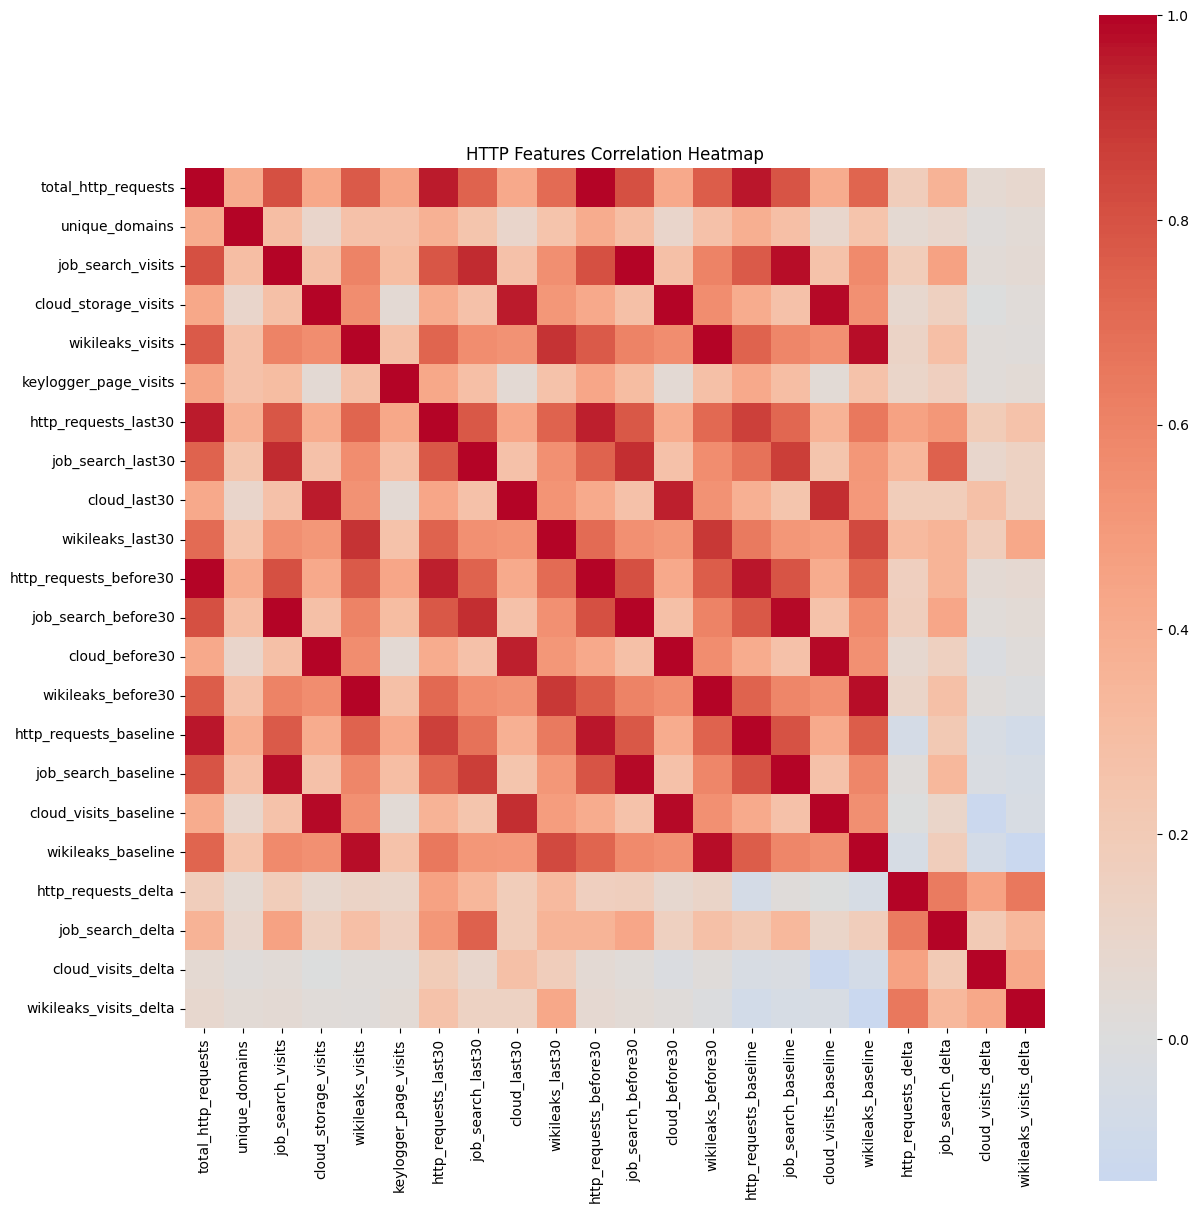

In [137]:
# HTTP features
plot_feature_heatmap(
    http_features,
    title="HTTP Features Correlation Heatmap"
)

We dropped these columns because they were redundant temporal duplicates—such as _before30 and _baseline—which mirrored the information in our last30 and delta features, causing high multicollinearity that confused the model. We also removed unique_domains because it was strongly correlated with the total request volume and provided no distinct behavioral signal.

In [138]:
## Drop redundant or highly correlated HTTP features
http_drop_cols = [
    'total_http_requests',
    'http_requests_before30',
    'http_requests_baseline',
    'job_search_visits',
    'job_search_before30',
    'job_search_baseline',
    'cloud_storage_visits',
    'cloud_before30',
    'cloud_visits_baseline',
    'wikileaks_visits',
    'wikileaks_before30',
    'wikileaks_baseline',
    "unique_domains",
    "http_keylogger_baseline",
    "http_sensitive_before30"
]

http_features = drop_features(http_features, http_drop_cols)
print(http_features.describe())

Dropping 13 column(s): ['total_http_requests', 'http_requests_before30', 'http_requests_baseline', 'job_search_visits', 'job_search_before30', 'job_search_baseline', 'cloud_storage_visits', 'cloud_before30', 'cloud_visits_baseline', 'wikileaks_visits', 'wikileaks_before30', 'wikileaks_baseline', 'unique_domains']
Remaining columns: 10
       keylogger_page_visits  http_requests_last30  job_search_last30  \
count             2000.00000           2000.000000        2000.000000   
mean               402.39000           1619.643500         177.463500   
std                606.28139           1323.016498         190.657937   
min                  0.00000              0.000000           0.000000   
25%                 63.00000            217.500000          32.750000   
50%                221.00000           1995.000000         112.000000   
75%                496.25000           2394.000000         268.250000   
max               7739.00000           9975.000000        2083.000000   

     

In [139]:
## email feature 
def build_email_features(email_df, ts_col="ts", days_window=30, internal_domain="dtaa.com"):
  
    df = email_df.copy()


    if "user_id" not in df.columns:
        if "user" in df.columns:
            df = df.rename(columns={"user": "user_id"})
        else:
            raise KeyError("Expected a 'user_id' or 'user' column in email_df")

    if ts_col not in df.columns:
        if "date" in df.columns:
            ts_col = "date"
        else:
            raise KeyError(
                f"Timestamp column '{ts_col}' not found in email_df and no 'date' column present. "
                f"Available columns: {df.columns.tolist()}"
            )

    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=["user_id", ts_col])
    if df.empty:
        return pd.DataFrame(columns=["user_id"]), df

    df = df.rename(columns={ts_col: "ts"})


    # Recipients as strings
    for col in ["to", "cc", "bcc"]:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str)

    # Email size
    if "size" not in df.columns:
        df["size"] = 0
    df["size"] = pd.to_numeric(df["size"], errors="coerce").fillna(0)

    # attachment_count - else 0
    if "attachment_count" in df.columns:
        df["attachments"] = pd.to_numeric(df["attachment_count"], errors="coerce").fillna(0)
    elif "attachments" in df.columns:
        df["attachments"] = pd.to_numeric(df["attachments"], errors="coerce").fillna(0)
    else:
        df["attachments"] = 0

    

    df["recipients"] = df["to"] + ";" + df["cc"] + ";" + df["bcc"]
    df["recipients_lower"] = df["recipients"].str.lower()

    #  using @ to count 
    df["recipient_count"] = df["recipients"].str.count("@")

    df["is_mass_email"] = (df["recipient_count"] >= 10).astype(int)

    df["has_bcc"] = df["bcc"].str.strip().ne("").astype(int)

    #external / personal email flags

    internal_pattern = "@" + internal_domain.lower()
    df["has_internal_recipient"] = df["recipients_lower"].str.contains(internal_pattern, na=False)
    df["has_non_internal_recipient"] = (
        df["recipients_lower"].str.contains("@", na=False)
        & ~df["recipients_lower"].str.contains(internal_pattern, na=False)
    )

    personal_domains_pattern = (
        "gmail.com|yahoo.com|hotmail.com|outlook.com|live.com|aol.com|"
        "comcast.net|verizon.net|icloud.com|msn.com|netzero.com|earthlink.net|"
        "bellsouth.net|sbcglobal.net|juno.com|cox.net"
    )

    df["is_personal_email"] = df["recipients_lower"].str.contains(
        personal_domains_pattern, na=False
    ).astype(int)

    # External emails-  any non-internal domain
    df["is_external_email"] = df["has_non_internal_recipient"].astype(int)

  

    if "content" in df.columns:
        df["content_str"] = df["content"].astype(str).str.lower()
    else:
        df["content_str"] = ""

    def contains_any(text: str, terms):
        return any(t in text for t in terms)

    keyword_groups = {
        # Scenario 1 – wikileaks exfil
        "is_wikileaks_email": ["wikileaks","leak ","leaked ",],
        "is_dropbox_email": [ "dropbox","box.com","onedrive", "gdrive","google drive",],      

        # Scenario 2 – job search + dissatisfaction / leaving
        "is_job_email": [
            "job ","jobs ","career","position",
            "opportunity","interview","resume","cv ","hiring","recruiter","offer",
            "reference", "negotiation", "salary", "attached resume", 
            "application", "cover letter"
        ],
        "is_resignation_email": [
            "resign","resignation", "two weeks","notice","last day","final day",
            "leaving the company","i may leave","i will leave","my work not appreciated",
            "fed up","no gratitude","company will suffer",
        ],

        # Scenario 3 – alarming mass email causing panic + keylogger
        "is_panic_email": [
            "urgent","immediately","emergency",
            "panic","security breach","compromised","do not",
            "all employees","bad things", "outraged","take me seriously",
            "virus", "trojan", "detected", "fatal", "shutdown", "alert", 
            "warning", "attack", "hacker", "infection", "critical"
        ],
        "is_keylogger_email": [
            "keylogger","keylogging","keystroke logger",
            "spyware","monitoring tool",
        ],
        
    
    }

    for col_name, terms in keyword_groups.items():
        df[col_name] = df["content_str"].apply(
            lambda txt, ts=terms: 1 if contains_any(txt, ts) else 0
        )

    # baseline all time stats

    base = df.groupby("user_id").agg(
        emails_sent=("ts", "count"),
        avg_email_size=("size", "mean"),
        total_email_size=("size", "sum"),
        emails_with_attachments=("attachments", "sum"),
        emails_with_bcc=("has_bcc", "sum"),
        mass_email_count=("is_mass_email", "sum"),
        external_emails_sent=("is_external_email", "sum"),
        personal_emails_sent=("is_personal_email", "sum"),
        sent_from_unique_pcs=("pc", "nunique"),
       
        # Scenario keyword totals
        job_emails_sent=("is_job_email", "sum"),
        panic_emails_sent=("is_panic_email", "sum"),
        keylogger_emails_sent=("is_keylogger_email", "sum"),
        wikileaks_emails_sent=("is_wikileaks_email", "sum"),
        dropbox_emails_sent=("is_dropbox_email", "sum"),
        resignation_emails_sent=("is_resignation_email", "sum"),
    )


    max_ts = df["ts"].max()
    cutoff = max_ts - pd.Timedelta(days=days_window)
    df["is_last_window"] = df["ts"] >= cutoff

    # Last window 
    last = df[df["is_last_window"]].groupby("user_id").agg(
        emails_last_window=("ts", "count"),
        external_emails_last_window=("is_external_email", "sum"),
        personal_emails_last_window=("is_personal_email", "sum"),
        mass_emails_last_window=("is_mass_email", "sum"),
        job_emails_last_window=("is_job_email", "sum"),
        panic_emails_last_window=("is_panic_email", "sum"),
        keylogger_emails_last_window=("is_keylogger_email", "sum"),
        wikileaks_emails_last_window=("is_wikileaks_email", "sum"),
        dropbox_emails_last_window=("is_dropbox_email", "sum"),
        resignation_emails_last_window=("is_resignation_email", "sum"),
    )

    # Before last window
    before = df[~df["is_last_window"]].groupby("user_id").agg(
        emails_before_window=("ts", "count"),
        external_emails_before_window=("is_external_email", "sum"),
        personal_emails_before_window=("is_personal_email", "sum"),
        mass_emails_before_window=("is_mass_email", "sum"),
        job_emails_before_window=("is_job_email", "sum"),
        panic_emails_before_window=("is_panic_email", "sum"),
        keylogger_emails_before_window=("is_keylogger_email", "sum"),
        wikileaks_emails_before_window=("is_wikileaks_email", "sum"),
        dropbox_emails_before_window=("is_dropbox_email", "sum"),
        resignation_emails_before_window=("is_resignation_email", "sum"),
    )

    features = (
        base.join(last, how="left")
            .join(before, how="left")
            .fillna(0)
    )


    df["year_month"] = df["ts"].dt.to_period("M")
    historical = df[df["ts"] < cutoff]

    if not historical.empty:
        monthly = historical.groupby(["user_id", "year_month"]).agg(
            monthly_emails=("ts", "count"),
            monthly_external_emails=("is_external_email", "sum"),
            monthly_personal_emails=("is_personal_email", "sum"),
            monthly_mass_emails=("is_mass_email", "sum"),
            monthly_job_emails=("is_job_email", "sum"),
            monthly_panic_emails=("is_panic_email", "sum"),
            monthly_keylogger_emails=("is_keylogger_email", "sum"),
            monthly_wikileaks_emails=("is_wikileaks_email", "sum"),
            monthly_dropbox_emails=("is_dropbox_email", "sum"),
            monthly_resignation_emails=("is_resignation_email", "sum"),
        ).reset_index()

        baselines = monthly.groupby("user_id").agg(
            emails_baseline=("monthly_emails", "mean"),
            external_emails_baseline=("monthly_external_emails", "mean"),
            personal_emails_baseline=("monthly_personal_emails", "mean"),
            mass_emails_baseline=("monthly_mass_emails", "mean"),
            job_emails_baseline=("monthly_job_emails", "mean"),
            panic_emails_baseline=("monthly_panic_emails", "mean"),
            keylogger_emails_baseline=("monthly_keylogger_emails", "mean"),
            wikileaks_emails_baseline=("monthly_wikileaks_emails", "mean"),
            dropbox_emails_baseline=("monthly_dropbox_emails", "mean"),
            resignation_emails_baseline=("monthly_resignation_emails", "mean"),
        )
    else:
        baselines = pd.DataFrame(
            0,
            index=features.index,
            columns=[
                "emails_baseline",
                "external_emails_baseline",
                "personal_emails_baseline",
                "mass_emails_baseline",
                "job_emails_baseline",
                "panic_emails_baseline",
                "keylogger_emails_baseline",
                "wikileaks_emails_baseline",
                "dropbox_emails_baseline",
                "resignation_emails_baseline",
            ],
        )

    features = features.join(baselines, how="left").fillna(0)

    # delta calculations

    features["emails_delta"] = (
        features["emails_last_window"] - features["emails_baseline"]
    )
    features["external_emails_delta"] = (
        features["external_emails_last_window"] - features["external_emails_baseline"]
    )
    features["personal_emails_delta"] = (
        features["personal_emails_last_window"] - features["personal_emails_baseline"]
    )
    features["mass_emails_delta"] = (
        features["mass_emails_last_window"] - features["mass_emails_baseline"]
    )

    # Scenario keyword deltas
    features["job_emails_delta"] = (
        features["job_emails_last_window"] - features["job_emails_baseline"]
    )
    features["panic_emails_delta"] = (
        features["panic_emails_last_window"] - features["panic_emails_baseline"]
    )
    features["keylogger_emails_delta"] = (
        features["keylogger_emails_last_window"] - features["keylogger_emails_baseline"]
    )
    features["wikileaks_emails_delta"] = (
        features["wikileaks_emails_last_window"] - features["wikileaks_emails_baseline"]
    )
    features["dropbox_emails_delta"] = (
        features["dropbox_emails_last_window"] - features["dropbox_emails_baseline"]
    )
    features["resignation_emails_delta"] = (
        features["resignation_emails_last_window"] - features["resignation_emails_baseline"]
    )

    return features.reset_index(), df

email_features, processed_email_df = build_email_features(email, ts_col="ts", days_window=30)

print(email_features.head())
print(email_features.describe())

   user_id  emails_sent  avg_email_size  total_email_size  \
0  AAB1302         3473   321033.689893        1114950005   
1  AAB1762         5517   493284.938916        2721453008   
2  AAC0904        17859   498789.500644        8907881692   
3  AAC1033         1504   299094.772606         449838538   
4  AAC1489        13716   240687.715733        3301272709   

   emails_with_attachments  emails_with_bcc  mass_email_count  \
0                      0.0                0                 0   
1                      0.0              513                 0   
2                      0.0                0                 0   
3                      0.0                0                 0   
4                      0.0                0                 0   

   external_emails_sent  personal_emails_sent  sent_from_unique_pcs  ...  \
0                  1334                  1224                     1  ...   
1                  1632                  1623                     1  ...   
2             

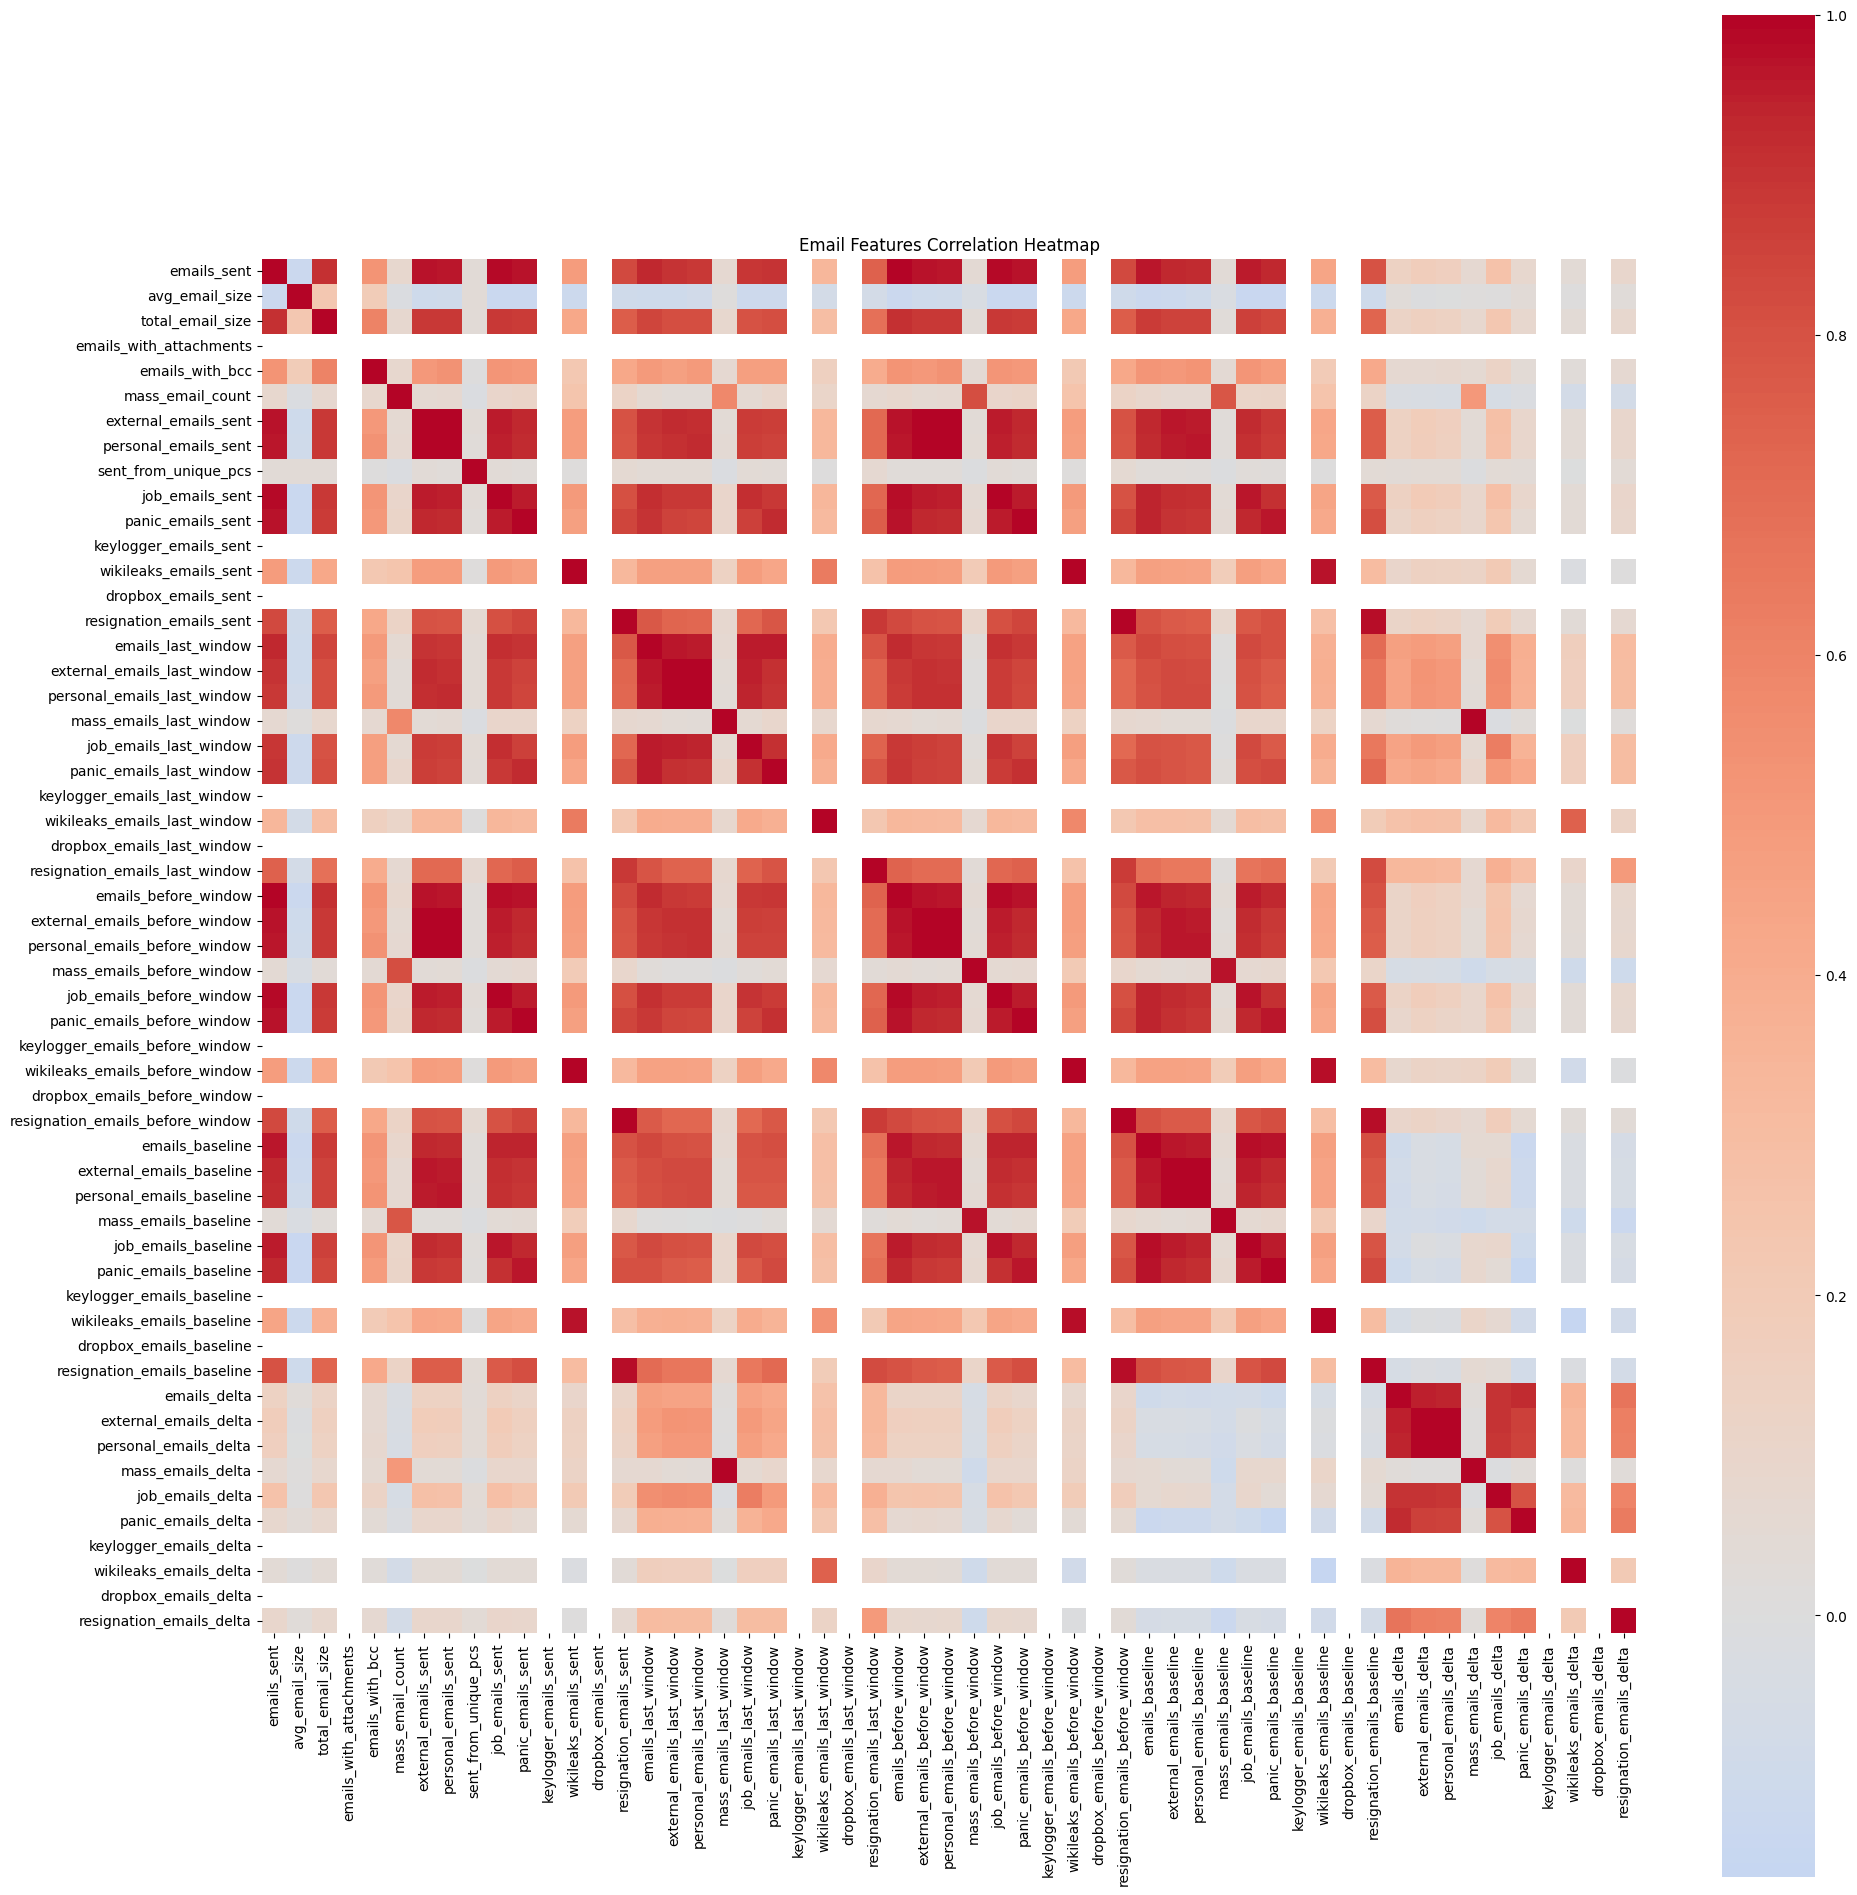

In [140]:
# Email features
plot_feature_heatmap(
    email_features,
    title="Email Features Correlation Heatmap"
)

We dropped these columns because they were redundant temporal duplicates—such as _before_window and _baseline—which mirrored the information in our last30 and delta features, causing high multicollinearity that confused the model. We also removed aggregate metrics like total_email_size and emails_with_attachments as they were strongly correlated with the total email count and provided no unique behavioral signal. All teh zero values have been retained as these are generic keyword searches which could be a part of future datasets.

In [141]:

email_drop_cols = [
    'total_emails_size',
    'emails_sent',
    'emails_before_window',
    'emails_baseline',
    'external_emails_sent',
    'external_emails_before_window',
    'external_emails_baseline',
    'personal_emails_sent',
    'personal_emails_before_window',
    'personal_emails_baseline',
    'job_emails_sent',
    'job_emails_before_window',
    'job_emails_baseline',
    'panic_emails_sent',
    'panic_emails_before_window',
    'panic_emails_baseline',
    'resignation_emails_sent',
    'resignation_emails_before_window',
    'resignation_emails_baseline',
    'wikileaks_emails_sent',
    'wikileaks_emails_before_window',
    'wikileaks_emails_baseline',
    "avg_email_size",
    "emails_with_bcc",
    "emails_with_attachments",
    "total_email_size",
    "sent_from_unique_pcs",
    "mass_email_count",
    "mass_emails_baseline",
    "keylogger_emails_baseline",
    "dropbox_emails_baseline",
    "wikileaks_baseline",
    "mass_emails_before_window",
    "keylogger_emails_before_window",
    "dropbox_emails_before_window",
    "keylogger_emails_sent", 
    "dropbox_emails_sent"
]
email_features = drop_features(email_features, email_drop_cols)
print(email_features.describe())

Dropping 35 column(s): ['emails_sent', 'emails_before_window', 'emails_baseline', 'external_emails_sent', 'external_emails_before_window', 'external_emails_baseline', 'personal_emails_sent', 'personal_emails_before_window', 'personal_emails_baseline', 'job_emails_sent', 'job_emails_before_window', 'job_emails_baseline', 'panic_emails_sent', 'panic_emails_before_window', 'panic_emails_baseline', 'resignation_emails_sent', 'resignation_emails_before_window', 'resignation_emails_baseline', 'wikileaks_emails_sent', 'wikileaks_emails_before_window', 'wikileaks_emails_baseline', 'avg_email_size', 'emails_with_bcc', 'emails_with_attachments', 'total_email_size', 'sent_from_unique_pcs', 'mass_email_count', 'mass_emails_baseline', 'keylogger_emails_baseline', 'dropbox_emails_baseline', 'mass_emails_before_window', 'keylogger_emails_before_window', 'dropbox_emails_before_window', 'keylogger_emails_sent', 'dropbox_emails_sent']
Remaining columns: 21
       emails_last_window  external_emails_last

In [142]:
## logon feature extraction 
def infer_assigned_pcs(logon_df):
    df = logon_df.copy()
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    df = df.dropna(subset=["user_id", "ts"])

    # Only consider logon events for assignment
    df["activity_lower"] = df["activity"].astype(str).str.lower()
    df = df[df["activity_lower"] == "logon"]
    if df.empty:
        return pd.DataFrame(columns=["user_id", "assigned_pc"])

    first_month_period = df["ts"].min().to_period("M")
    first_month = df[df["ts"].dt.to_period("M") == first_month_period]

    counts = (
        first_month.groupby(["user_id", "pc"])
        .size()
        .reset_index(name="cnt")
        .sort_values(["user_id", "cnt"], ascending=[True, False])
    )

    # Take the PC with highest count per user_id as assigned PC 
    assigned_pc = (
        counts.groupby("user_id")
        .first()
        .reset_index()[["user_id", "pc"]]
        .rename(columns={"pc": "assigned_pc"})
    )

    return assigned_pc




def build_logon_features_from_clean(logon_df, days_window=30, assigned_pc_df=None):
    df = logon_df.copy()

    
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    df = df.dropna(subset=["user_id", "ts"])
    if df.empty:
        return pd.DataFrame(columns=["user_id"]), pd.DataFrame(columns=[])

    df["activity"] = df["activity"].astype(str).str.strip()
    df["activity_lower"] = df["activity"].str.lower()
    df = df[df["activity_lower"].isin(["logon", "logoff"])]
    if df.empty:
        return pd.DataFrame(columns=["user_id"]), pd.DataFrame(columns=[])

    df["is_logon"] = df["activity_lower"] == "logon"
    df["is_logoff"] = df["activity_lower"] == "logoff"

    if assigned_pc_df is None:
        assigned_pc_df = infer_assigned_pcs(df)

    df = df.merge(assigned_pc_df, on="user_id", how="left")

    # foreign_pc_logon is different from assigned_pc
    df["foreign_pc_logon"] = (
        df["is_logon"]
        & df["assigned_pc"].notna()
        & (df["pc"] != df["assigned_pc"])
    ).astype(int)

    
    df["hour"] = df["ts"].dt.hour + df["ts"].dt.minute / 60.0
    df["weekday"] = df["ts"].dt.weekday
    df["is_weekend"] = df["weekday"] >= 5

    df["is_after_hours_logon"] = df["is_logon"] & (
        (df["hour"] < 8) | (df["hour"] >= 18)
    )
    df["is_weekend_logon"] = df["is_logon"] & df["is_weekend"]

    g = df.groupby("user_id")

    event_agg = g.agg(
        logon_count=("is_logon", "sum"),
        logoff_count=("is_logoff", "sum"),
        unique_pc_count=("pc", "nunique"),
        logon_days_active=("ts", lambda x: x.dt.date.nunique()),
        after_hours_logons=("is_after_hours_logon", "sum"),
        weekend_logons=("is_weekend_logon", "sum"),
        foreign_pc_logon_count=("foreign_pc_logon", "sum"),
    )

    
    foreign_pc_unique = g.apply(
        lambda x: x.loc[x["foreign_pc_logon"] == 1, "pc"].nunique()
    ).rename("foreign_pc_unique_pcs")

    event_agg = event_agg.join(foreign_pc_unique, how="left").fillna(0)

    # sessions from logon to logout 
    df_sorted = df.sort_values(["user_id", "pc", "ts"])
    sessions = []

    for (user, pc), grp in df_sorted.groupby(["user_id", "pc"], sort=False):
        open_start = None
        for _, row in grp.iterrows():
            ts = row["ts"]
            act = row["activity_lower"]

            if act == "logon":
                if open_start is None:
                    open_start = ts
            elif act == "logoff":
                if open_start is not None and ts >= open_start:
                    duration_min = (ts - open_start).total_seconds() / 60.0
                    sessions.append(
                        {
                            "user_id": user,
                            "pc": pc,
                            "session_start": open_start,
                            "session_end": ts,
                            "session_duration_min": duration_min,
                        }
                    )
                    open_start = None

    session_df = pd.DataFrame(sessions)

    if session_df.empty:
        features = event_agg.copy()
        zero_cols = [
            "session_count", "session_days_active",
            "session_duration_mean_min", "session_duration_std_min",
            "session_duration_max_min", "session_duration_sum_min",
            "after_hours_sessions", "weekend_sessions",
            "sessions_per_active_day",
            "after_hours_session_ratio", "weekend_session_ratio",
            "session_count_win_last30", "session_days_win_last30",
            "session_count_win_before30", "session_days_win_before30",
            "session_usage_rate_last30", "session_usage_rate_before30",
            "session_baseline", "session_usage_rate_baseline",
            "session_usage_rate_delta",
            "foreign_pc_logon_last30", "foreign_pc_logon_before30",
            "foreign_pc_logon_baseline", "foreign_pc_logon_delta",
        ]
        for c in zero_cols:
            features[c] = 0.0
        return features.reset_index(), session_df

    # session agrregate 
    session_df["date_only"] = session_df["session_start"].dt.date
    session_df["start_hour"] = (
        session_df["session_start"].dt.hour
        + session_df["session_start"].dt.minute / 60.0
    )
    session_df["end_hour"] = (
        session_df["session_end"].dt.hour
        + session_df["session_end"].dt.minute / 60.0
    )
    session_df["weekday"] = session_df["session_start"].dt.weekday
    session_df["is_weekend"] = session_df["weekday"] >= 5

    session_df["is_after_hours_session"] = (
        (session_df["start_hour"] < 8)
        | (session_df["start_hour"] >= 18)
        | (session_df["end_hour"] < 8)
        | (session_df["end_hour"] >= 18)
    )

    sess_agg = session_df.groupby("user_id").agg(
        session_count=("session_start", "count"),
        session_days_active=("date_only", "nunique"),
        session_duration_mean_min=("session_duration_min", "mean"),
        session_duration_std_min=("session_duration_min", "std"),
        session_duration_max_min=("session_duration_min", "max"),
        session_duration_sum_min=("session_duration_min", "sum"),
        after_hours_sessions=("is_after_hours_session", "sum"),
        weekend_sessions=("is_weekend", "sum"),
    )

    sess_agg["sessions_per_active_day"] = (
        sess_agg["session_count"]
        / sess_agg["session_days_active"].replace(0, np.nan)
    )

    sess_agg["after_hours_session_ratio"] = (
        sess_agg["after_hours_sessions"]
        / sess_agg["session_count"].replace(0, np.nan)
    )

    sess_agg["weekend_session_ratio"] = (
        sess_agg["weekend_sessions"]
        / sess_agg["session_count"].replace(0, np.nan)
    )

    
    max_ts = session_df["session_start"].max()
    cutoff = max_ts - pd.Timedelta(days=days_window)
    session_df["is_last_window"] = session_df["session_start"] >= cutoff

    def agg_window(subset):
        if subset.empty:
            return pd.DataFrame(
                columns=["user_id", "session_count_win", "session_days_win"]
            ).set_index("user_id")
        g2 = subset.groupby("user_id").agg(
            session_count_win=("session_start", "count"),
            session_days_win=("date_only", "nunique"),
        )
        return g2

    last = agg_window(session_df[session_df["is_last_window"]]).add_suffix("_last30")
    before = agg_window(session_df[~session_df["is_last_window"]]).add_suffix("_before30")

    # last 30 vs befor=e 30 
    df["is_last_window"] = df["ts"] >= cutoff

    foreign_last = (
        df[df["is_last_window"] & df["is_logon"]]
        .groupby("user_id")["foreign_pc_logon"]
        .sum()
        .rename("foreign_pc_logon_last30")
    )

    foreign_before = (
        df[~df["is_last_window"] & df["is_logon"]]
        .groupby("user_id")["foreign_pc_logon"]
        .sum()
        .rename("foreign_pc_logon_before30")
    )

    features = (
        event_agg.join(sess_agg, how="outer")
        .join(last, how="left")
        .join(before, how="left")
        .join(foreign_last, how="left")
        .join(foreign_before, how="left")
        .fillna(0)
    )

    # Session usage rates
    features["session_usage_rate_last30"] = (
        features["session_count_win_last30"]
        / features["session_days_win_last30"].replace(0, np.nan)
    ).fillna(0)

    features["session_usage_rate_before30"] = (
        features["session_count_win_before30"]
        / features["session_days_win_before30"].replace(0, np.nan)
    ).fillna(0)

    # baseline
    session_df["year_month"] = session_df["session_start"].dt.to_period("M")
    historical_sessions = session_df[session_df["session_start"] < cutoff]

    df["year_month"] = df["ts"].dt.to_period("M")
    historical_events = df[(df["ts"] < cutoff) & df["is_logon"]]

    if not historical_sessions.empty:
        monthly_sess = historical_sessions.groupby(["user_id", "year_month"]).agg(
            monthly_sessions=("session_start", "count"),
            monthly_days_active=("date_only", "nunique"),
        ).reset_index()

        monthly_sess["monthly_session_usage_rate"] = (
            monthly_sess["monthly_sessions"]
            / monthly_sess["monthly_days_active"].replace(0, np.nan)
        ).fillna(0)

        sess_baselines = monthly_sess.groupby("user_id").agg(
            session_baseline=("monthly_sessions", "mean"),
            session_usage_rate_baseline=("monthly_session_usage_rate", "mean"),
        )
    else:
        sess_baselines = pd.DataFrame(
            0,
            index=features.index,
            columns=["session_baseline", "session_usage_rate_baseline"],
        )

    if not historical_events.empty:
        monthly_foreign = historical_events.groupby(["user_id", "year_month"]).agg(
            monthly_foreign_pc_logons=("foreign_pc_logon", "sum"),
        ).reset_index()

        foreign_baselines = monthly_foreign.groupby("user_id").agg(
            foreign_pc_logon_baseline=("monthly_foreign_pc_logons", "mean")
        )
    else:
        foreign_baselines = pd.DataFrame(
            0,
            index=features.index,
            columns=["foreign_pc_logon_baseline"],
        )

    features = (
        features.join(sess_baselines, how="left")
        .join(foreign_baselines, how="left")
        .fillna(0)
    )

    # delta calculations
    features["session_usage_rate_delta"] = (
        features["session_usage_rate_last30"]
        - features["session_usage_rate_baseline"]
    )

    features["foreign_pc_logon_delta"] = (
        features["foreign_pc_logon_last30"]
        - features["foreign_pc_logon_baseline"]
    )

    return features.reset_index(), session_df
logon_features, processed_logon_sessions = build_logon_features_from_clean(logon, days_window=30, assigned_pc_df=None)
print(logon_features.head())
print(logon_features.describe())

/var/folders/fm/hn2fw38j1s13j_s14t_w33tc0000gn/T/ipykernel_32710/1285997022.py:89: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  foreign_pc_unique = g.apply(


   user_id  logon_count  logoff_count  unique_pc_count  logon_days_active  \
0  AAB1302          739           415                1                415   
1  AAB1762          669           390                4                362   
2  AAC0904          453           453                3                357   
3  AAC1033          357           357                1                357   
4  AAC1489          357           357                1                357   

   after_hours_logons  weekend_logons  foreign_pc_logon_count  \
0                   0              96                       0   
1                  24               5                      15   
2                   0               0                      96   
3                 169               0                       0   
4                 168               0                       0   

   foreign_pc_unique_pcs  session_count  ...  session_days_win_before30  \
0                      0            415  ...                        391

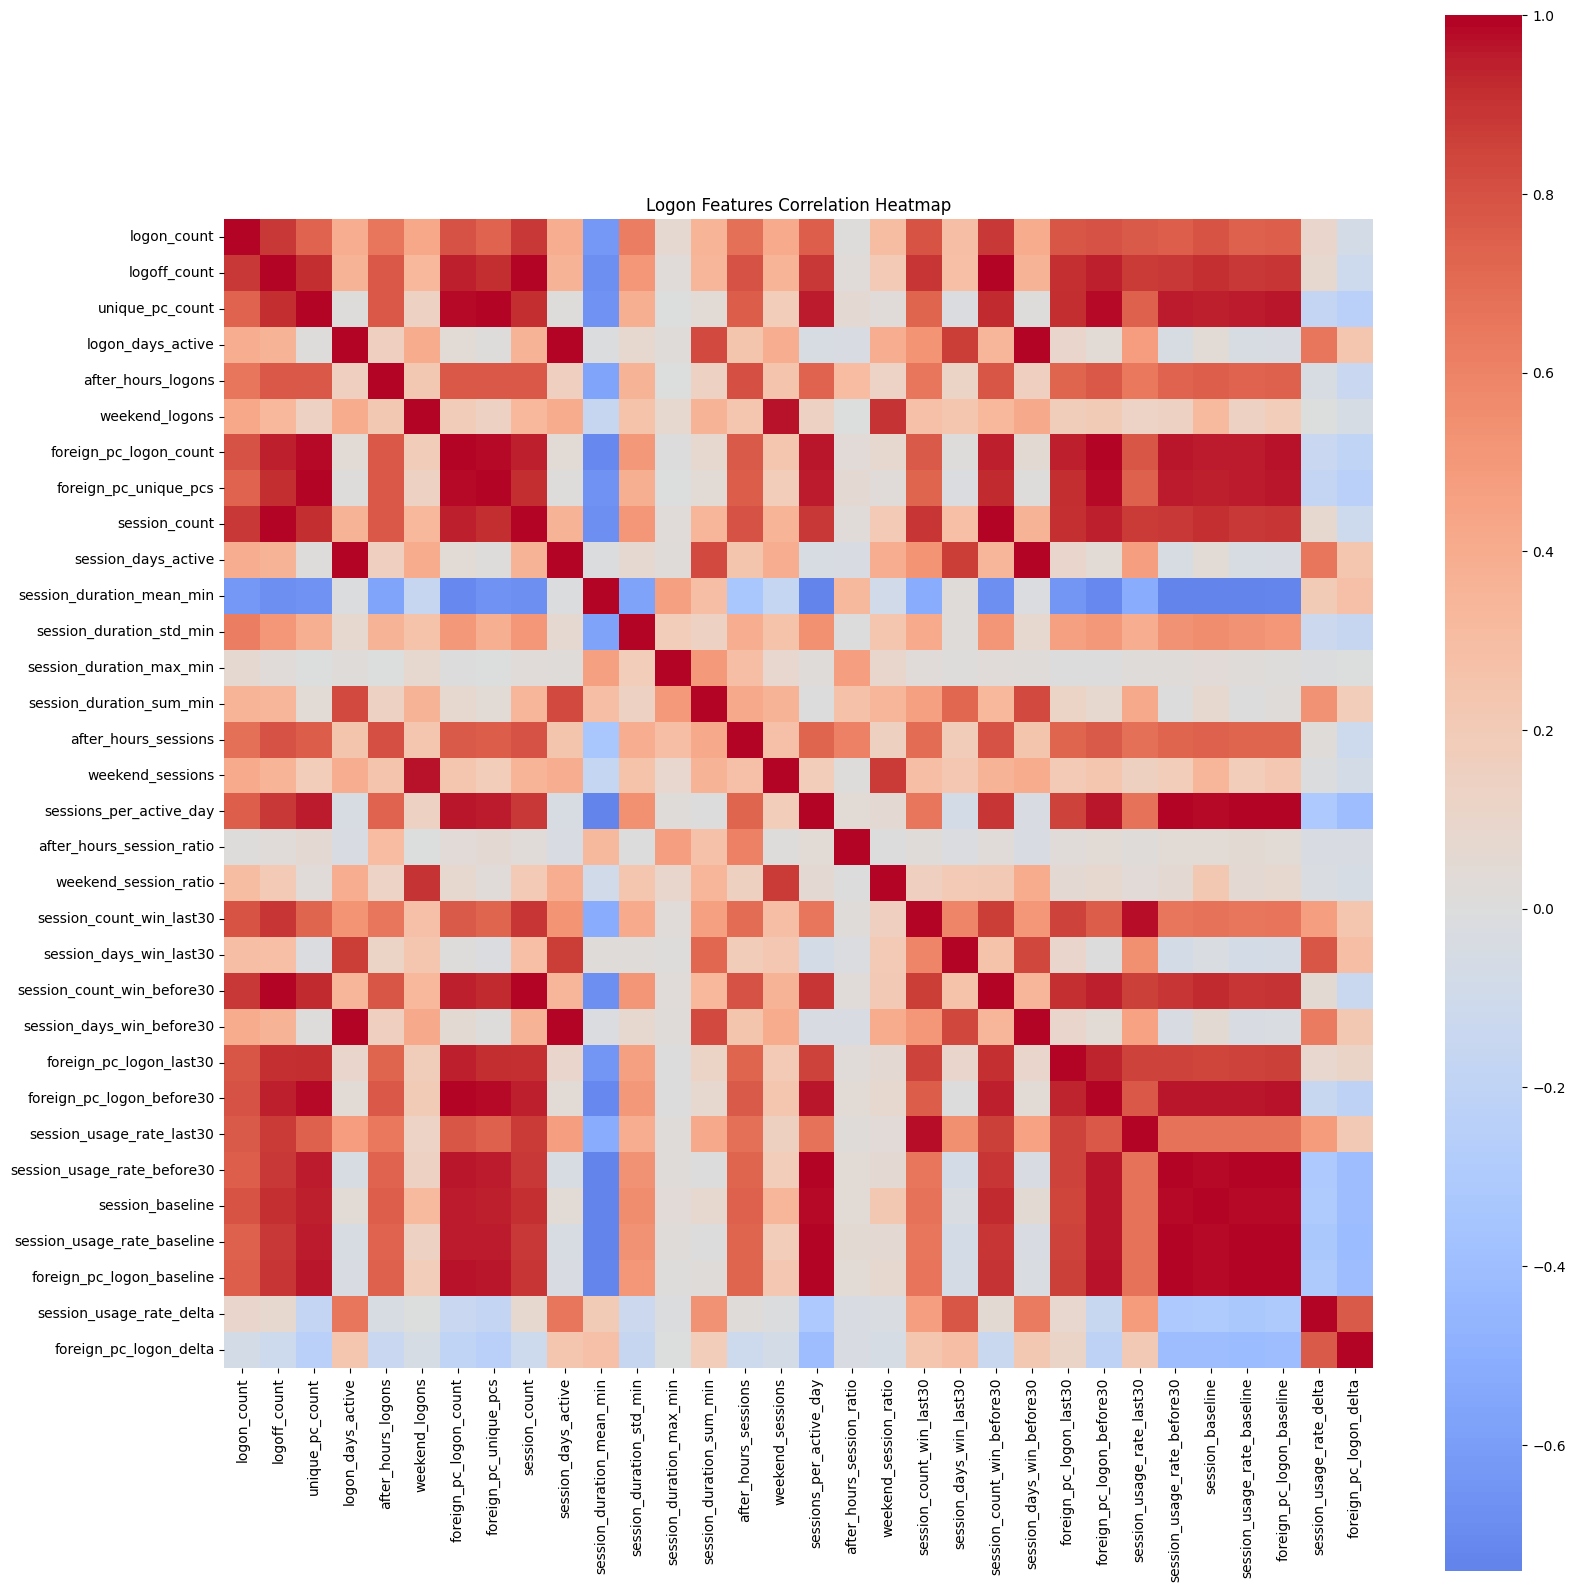

In [143]:
# Logon features
plot_feature_heatmap(
    logon_features,
    title="Logon Features Correlation Heatmap")

We dropped these columns because they were redundant metrics for the same underlying activity specifically, session_count and logon_count are functionally identical, and variables like duration_sum are just derivatives of mean × count. We also removed the split-window features (e.g., win_last30, before30, baseline) because they duplicated the signal already present in our total lifetime aggregates, creating noise without adding unique behavioral insight.

In [144]:

logon_drop_cols = [
    'logon_count',
    'logoff_count',
    'logon_days_active',
    'session_count',
    'session_days_active',
    'session_count_win_last30',
    'session_days_win_last30',
    'session_count_win_before30',
    'session_days_win_before30',
    'session_duration_std_min',
    'session_duration_sum_min',
    'session_duration_max_min',
    'session_usage_rate_before30',
    'session_usage_rate_baseline',
    "session_duration_mean_min",
    "weekend_sessions",
    "weekend_session_ratio",
    "after_hours_session_ratio",
    "sessions_per_active_day",
    "unique_pc_count",
    "session_baseline",
    "foreign_pc_logon_baseline",
    "foreign_pc_logon_before30",
    "foreign_pc_logon_count"
]

logon_features = drop_features(logon_features, logon_drop_cols)
print(logon_features.describe())

Dropping 24 column(s): ['logon_count', 'logoff_count', 'logon_days_active', 'session_count', 'session_days_active', 'session_count_win_last30', 'session_days_win_last30', 'session_count_win_before30', 'session_days_win_before30', 'session_duration_std_min', 'session_duration_sum_min', 'session_duration_max_min', 'session_usage_rate_before30', 'session_usage_rate_baseline', 'session_duration_mean_min', 'weekend_sessions', 'weekend_session_ratio', 'after_hours_session_ratio', 'sessions_per_active_day', 'unique_pc_count', 'session_baseline', 'foreign_pc_logon_baseline', 'foreign_pc_logon_before30', 'foreign_pc_logon_count']
Remaining columns: 9
       after_hours_logons  weekend_logons  foreign_pc_unique_pcs  \
count         2000.000000     2000.000000             2000.00000   
mean           192.776000       13.095500               31.80300   
std            238.729455       50.124311              151.52309   
min              0.000000        0.000000                0.00000   
25%       

We dropped these columns because they were redundant metrics for the same underlying activity—specifically, session_count and logon_count are functionally identical, and variables like duration_sum are just derivatives of mean × count. We also removed the split-window features (e.g., win_last30, before30, baseline) because they duplicated the signal already present in our total lifetime aggregates, creating noise without adding unique behavioral insight.

In [145]:
# MAster dataset construction
def ensure_one_row_per_user(df, name=""):
    if 'user_id' not in df.columns:
        raise ValueError(f"{name} has no user_id column.")

    if df['user_id'].duplicated().any():
        # aggregate duplicates by mean
        numeric_cols = df.select_dtypes(include=['number']).columns
        df = df.groupby('user_id')[numeric_cols].mean().reset_index()

    return df

device_features = ensure_one_row_per_user(device_features,"device")
file_features   = ensure_one_row_per_user(file_features, "file")
http_features  = ensure_one_row_per_user(http_features, "http")
email_features  = ensure_one_row_per_user(email_features, "email")
logon_features = ensure_one_row_per_user(logon_features, "logon")

all_users = pd.concat([
    device_features[['user_id']],
    file_features[['user_id']],
    http_features[['user_id']],
    email_features[['user_id']],
    logon_features[['user_id']]
]).drop_duplicates()

master_features_clean = all_users.copy()

feature_tables = [
    ('device', device_features),
    ('file', file_features),
    ('http', http_features),
    ('email', email_features),
    ('logon', logon_features),
]
insiders=pd.read_csv("insiders5.csv")
insiders= normalize_user_column(insiders)


for name, df_ft in feature_tables:
    master_features_clean = master_features_clean.merge(df_ft, on='user_id', how='left')

num_cols = master_features_clean.select_dtypes(include=['number']).columns
master_features_clean[num_cols] = master_features_clean[num_cols].fillna(0)

master = master_features_clean.merge(insiders, on='user_id', how='left')
master["scenario"] = master["scenario"].fillna(0).astype(int)
master = master.drop(columns=["dataset"])


print(master.shape)

(2073, 66)


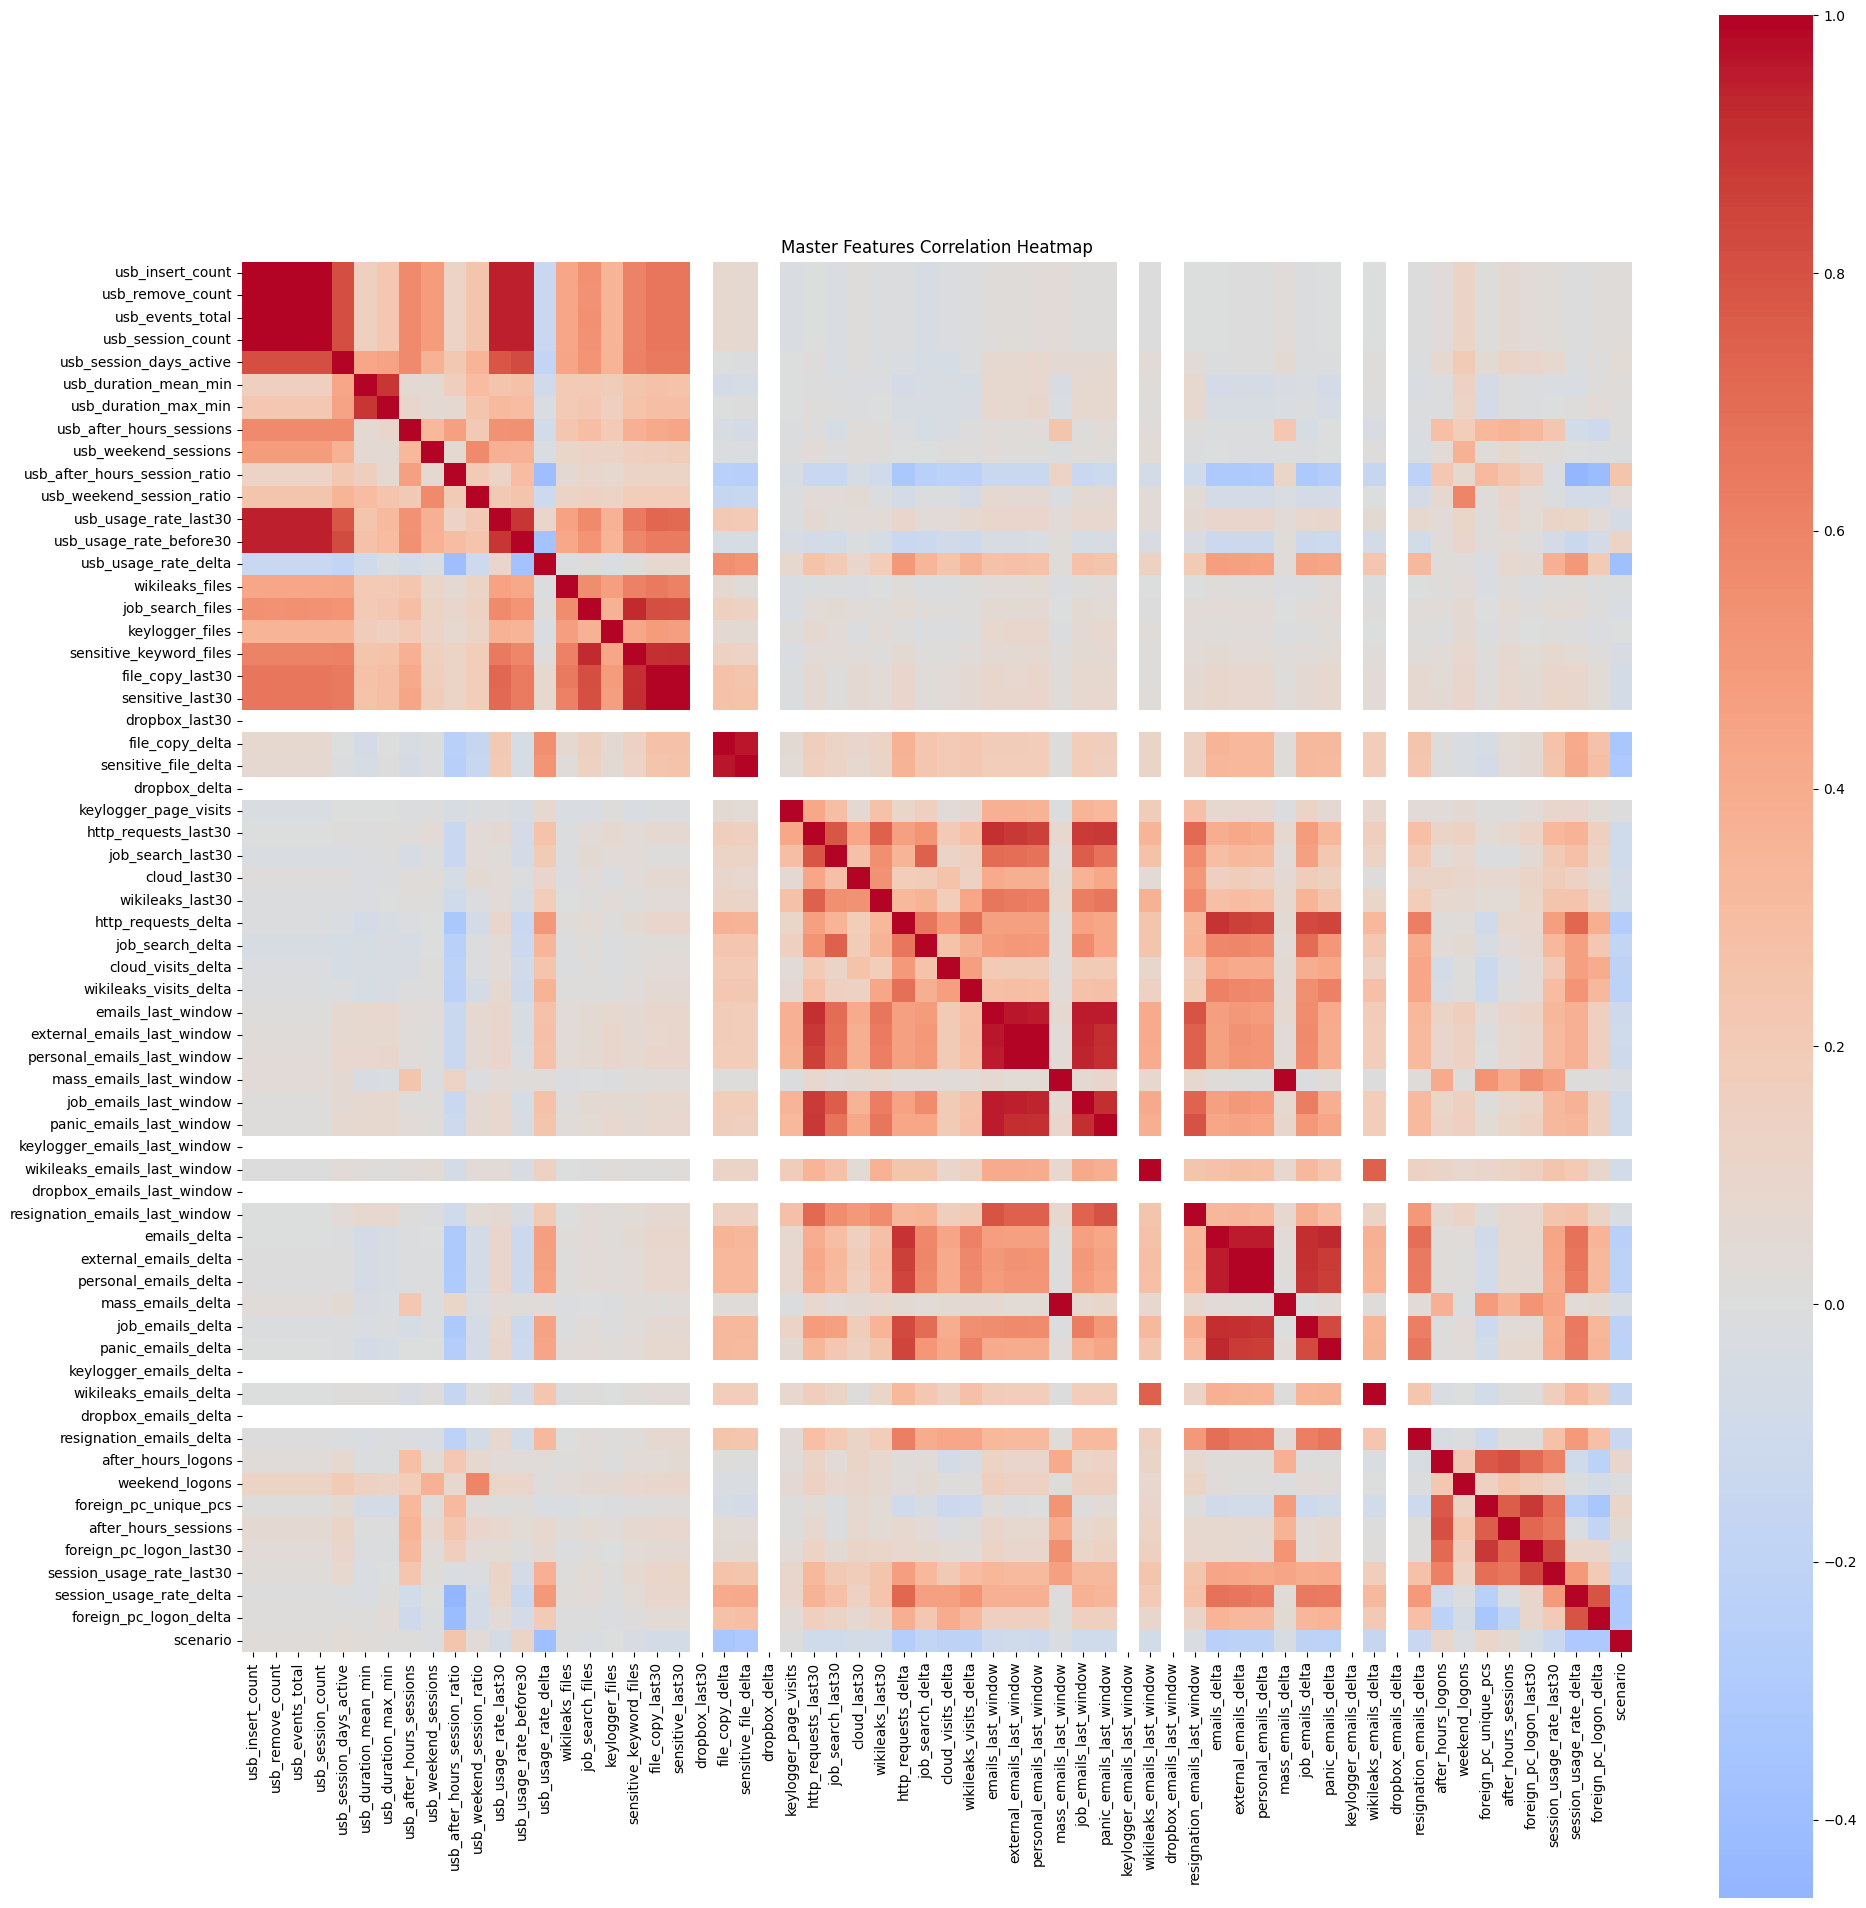

In [146]:

plot_feature_heatmap(
    master,
    title="Master Features Correlation Heatmap")

In [147]:
#Dropping rows with missing target
master_clf = master.dropna(subset=["scenario"]).copy()

y = master_clf["scenario"].astype(int)   # or .astype("int64") if you prefer
X = master_clf.drop(columns=["scenario", "user_id"], errors="ignore")
X = X.select_dtypes(include=["number"]).copy()

print("X columns (numeric only):")
print(X.columns.tolist())
print("X dtypes:\n", X.dtypes.value_counts())
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sample y values:\n", y.value_counts())


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

X columns (numeric only):
['usb_insert_count', 'usb_remove_count', 'usb_events_total', 'usb_session_count', 'usb_session_days_active', 'usb_duration_mean_min', 'usb_duration_max_min', 'usb_after_hours_sessions', 'usb_weekend_sessions', 'usb_after_hours_session_ratio', 'usb_weekend_session_ratio', 'usb_usage_rate_last30', 'usb_usage_rate_before30', 'usb_usage_rate_delta', 'wikileaks_files', 'job_search_files', 'keylogger_files', 'sensitive_keyword_files', 'file_copy_last30', 'sensitive_last30', 'dropbox_last30', 'file_copy_delta', 'sensitive_file_delta', 'dropbox_delta', 'keylogger_page_visits', 'http_requests_last30', 'job_search_last30', 'cloud_last30', 'wikileaks_last30', 'http_requests_delta', 'job_search_delta', 'cloud_visits_delta', 'wikileaks_visits_delta', 'emails_last_window', 'external_emails_last_window', 'personal_emails_last_window', 'mass_emails_last_window', 'job_emails_last_window', 'panic_emails_last_window', 'keylogger_emails_last_window', 'wikileaks_emails_last_window

stratify=y (in splitting): This ensures the data is divided fairly. It guarantees that if 2% of your users are insiders, your training set gets 2% and your test set gets 2%. It fixes the input distribution.

class_weight='balanced' (in the model): This changes the math. It tells the model to pay way more attention to the minority class (insiders). If insiders are 2% of the data, the model might treat every error on an insider as 50x more important than an error on a normal user. It fixes the learning penalty.

In [148]:

#Logistic Regression model

warnings.filterwarnings("ignore", category=UserWarning)
log_reg = LogisticRegression(
    class_weight="balanced",  
    max_iter=1000,           
    multi_class="multinomial", 
    solver="lbfgs",            
    n_jobs=-1                 
)

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1 Score:", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.9325301204819277
Macro F1 Score: 0.850952421312505

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       381
           1       1.00      1.00      1.00         6
           2       0.71      1.00      0.83        12
           3       1.00      1.00      1.00         4
           4       0.32      0.83      0.47        12

    accuracy                           0.93       415
   macro avg       0.80      0.95      0.85       415
weighted avg       0.97      0.93      0.94       415


Confusion Matrix:
[[355   0   5   0  21]
 [  0   6   0   0   0]
 [  0   0  12   0   0]
 [  0   0   0   4   0]
 [  2   0   0   0  10]]


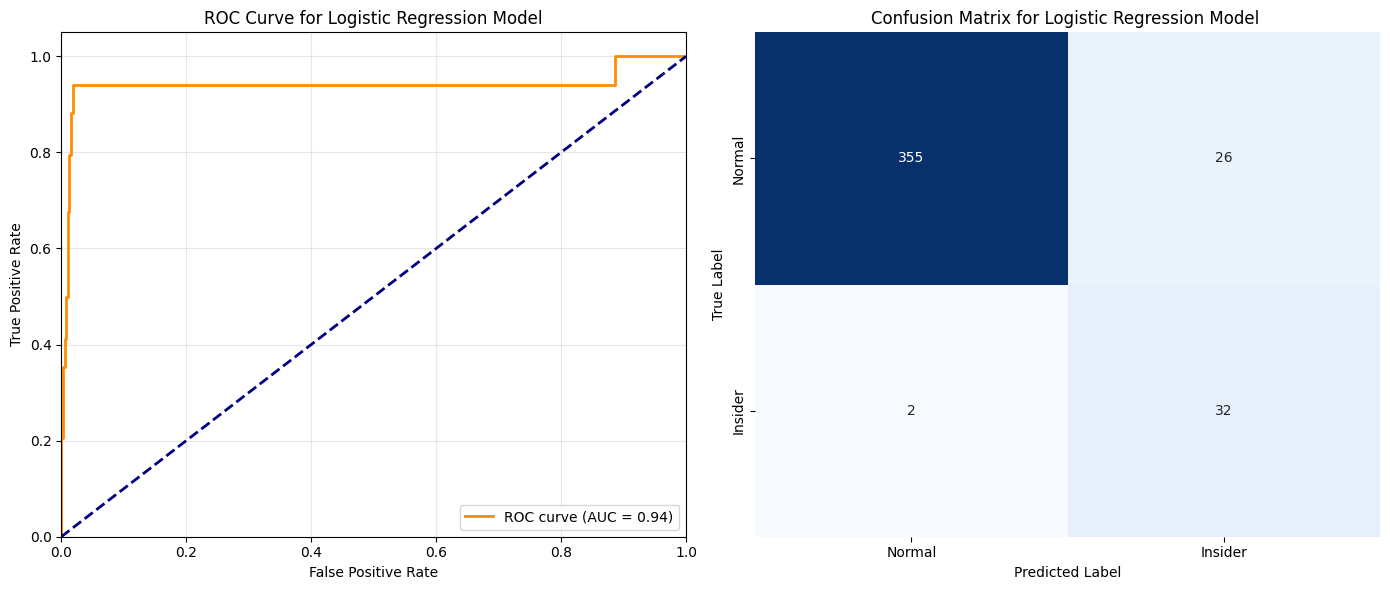

In [149]:
if hasattr(log_reg, "classes_") and len(log_reg.classes_) > 2:

    # We treat Class 0 as "Normal" and all other classes (1, 2, 3 and 4  as "Insider"
    y_prob = 1 - log_reg.predict_proba(X_test)[:, 0]
    y_test_plot = (y_test > 0).astype(int)
    y_pred_plot = (log_reg.predict(X_test) > 0).astype(int)
else:

    y_prob = log_reg.predict_proba(X_test)[:, 1]
    y_test_plot = y_test
    y_pred_plot = y_pred if 'y_pred' in locals() else log_reg.predict(X_test)

# ROC
fpr, tpr, thresholds = roc_curve(y_test_plot, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(14, 6))

#  ROC Curve 
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test_plot, y_pred_plot)

#heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Insider'], 
            yticklabels=['Normal', 'Insider'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model ')

plt.tight_layout()
plt.show()

In [150]:

#Random Forest 
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",   # handles class imbalance
    n_jobs=-1                  # use all CPU cores
)


rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1 Score:", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9903614457831326
Macro F1 Score: 0.9653836976671621

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       381
           1       1.00      1.00      1.00         6
           2       0.86      1.00      0.92        12
           3       1.00      1.00      1.00         4
           4       1.00      0.83      0.91        12

    accuracy                           0.99       415
   macro avg       0.97      0.97      0.97       415
weighted avg       0.99      0.99      0.99       415


Confusion Matrix:
[[379   0   2   0   0]
 [  0   6   0   0   0]
 [  0   0  12   0   0]
 [  0   0   0   4   0]
 [  2   0   0   0  10]]


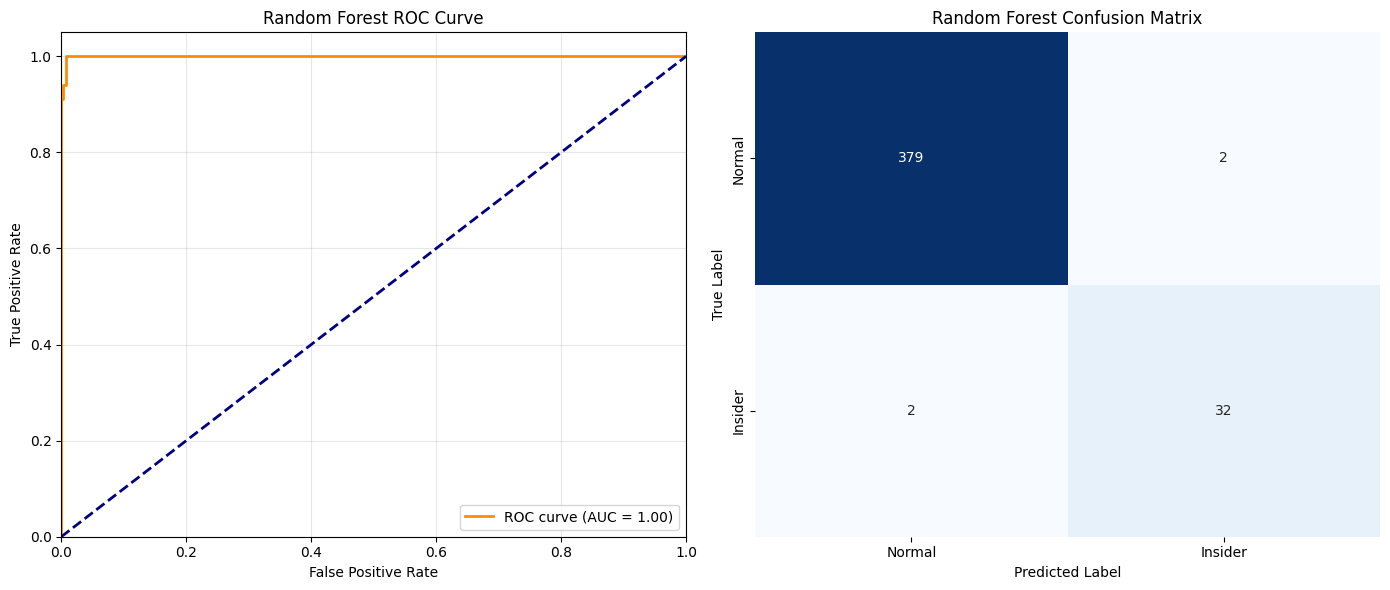

In [151]:
if hasattr(rf, "classes_") and len(rf.classes_) > 2:
    y_prob = 1 - rf.predict_proba(X_test)[:, 0]
    y_test_plot = (y_test > 0).astype(int)
    y_pred_plot = (rf.predict(X_test) > 0).astype(int)
else:
    y_prob = rf.predict_proba(X_test)[:, 1]
    y_test_plot = y_test
    y_pred_plot = rf.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test_plot, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test_plot, y_pred_plot)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Insider'], 
            yticklabels=['Normal', 'Insider'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()

Top 10 Feature Importances 
 foreign_pc_unique_pcs            0.079449
usb_after_hours_session_ratio    0.061344
file_copy_delta                  0.057233
foreign_pc_logon_delta           0.056857
session_usage_rate_delta         0.049677
sensitive_file_delta             0.046507
usb_events_total                 0.043045
usb_session_days_active          0.042840
usb_duration_max_min             0.039777
http_requests_delta              0.038537
dtype: float64


/var/folders/fm/hn2fw38j1s13j_s14t_w33tc0000gn/T/ipykernel_32710/3518970615.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_features.values, y=top_10_features.index, palette="viridis")


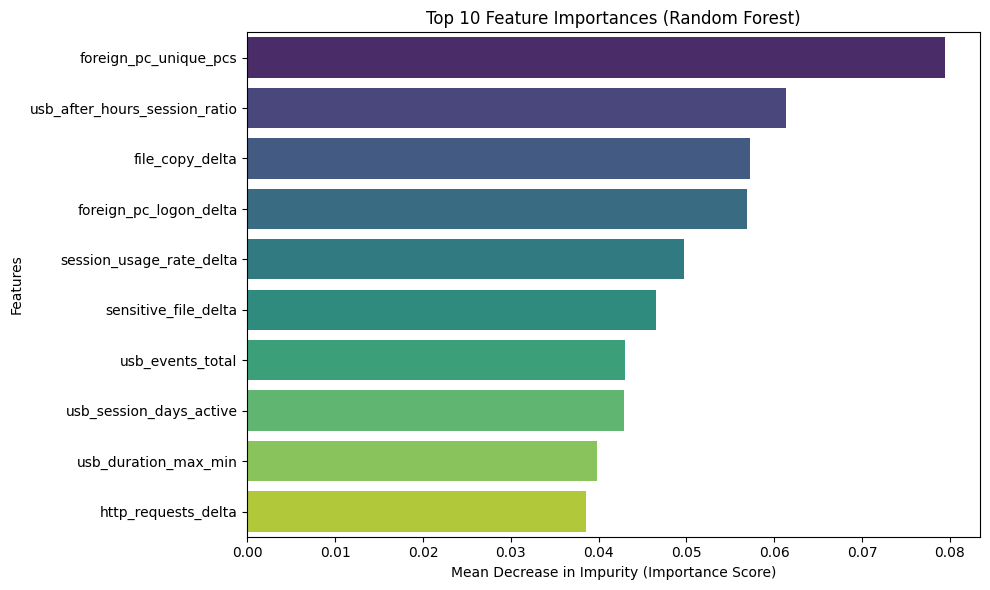

In [152]:
## Importance of features
importances = rf.feature_importances_
feature_names = X_test.columns
forest_importances = pd.Series(importances, index=feature_names)
top_10_features = forest_importances.sort_values(ascending=False).head(10)

print("Top 10 Feature Importances \n", top_10_features)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette="viridis")

plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Mean Decrease in Impurity (Importance Score)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [153]:
svm_clf = make_pipeline(
    StandardScaler(), 
    SVC(
        class_weight='balanced',  # Handle the class imbalance
        kernel='rbf',             # Radial Basis Function (good for non-linear boundaries)
        probability=True,         # Required if you want to plot ROC curves later
        random_state=42
    )
)

print("\nTraining SVM Model (this may take a moment)...")
svm_clf.fit(X_train, y_train)

# Generate Predictions
y_pred_svm = svm_clf.predict(X_test)

# Evaluation
print("-" * 30)
print("SVM Model Performance")
print("-" * 30)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Macro F1 Score:", f1_score(y_test, y_pred_svm, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))


Training SVM Model (this may take a moment)...
------------------------------
SVM Model Performance
------------------------------
Accuracy: 0.983132530120482
Macro F1 Score: 0.944001621566839

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       381
           1       1.00      1.00      1.00         6
           2       0.92      1.00      0.96        12
           3       1.00      1.00      1.00         4
           4       0.71      0.83      0.77        12

    accuracy                           0.98       415
   macro avg       0.93      0.96      0.94       415
weighted avg       0.98      0.98      0.98       415


Confusion Matrix:
[[376   0   1   0   4]
 [  0   6   0   0   0]
 [  0   0  12   0   0]
 [  0   0   0   4   0]
 [  2   0   0   0  10]]


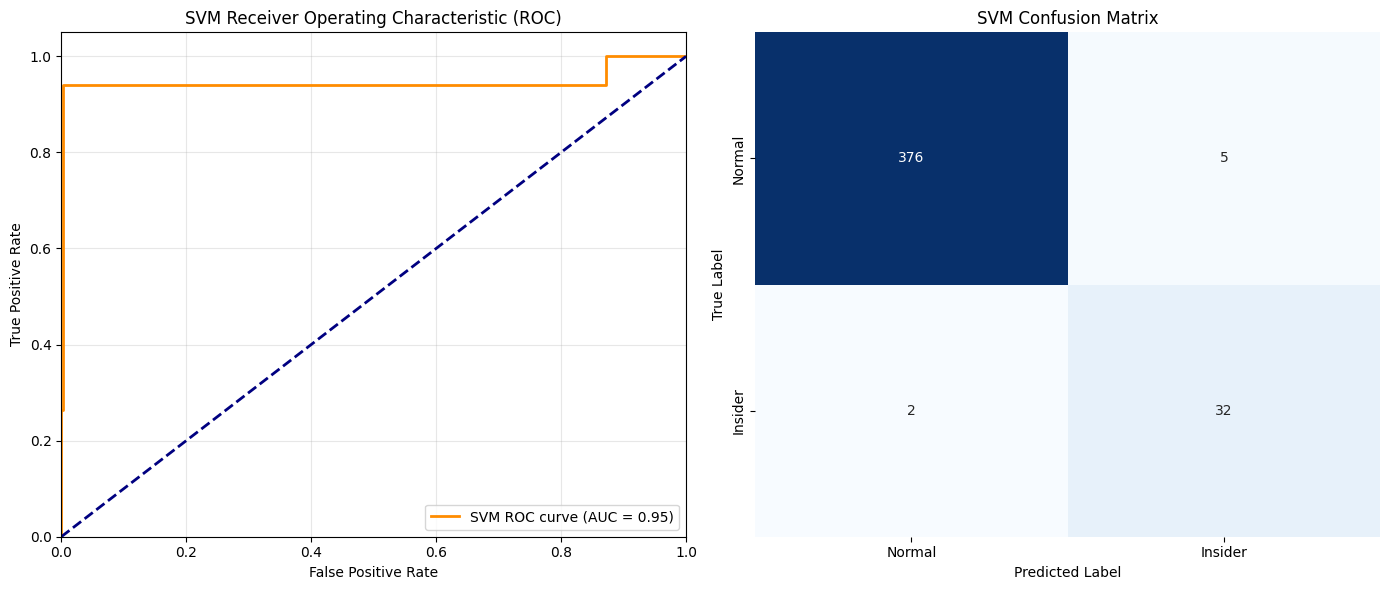

In [154]:
if hasattr(svm_clf.named_steps['svc'], "classes_") and len(svm_clf.named_steps['svc'].classes_) > 2:
    y_prob_svm = 1 - svm_clf.predict_proba(X_test)[:, 0]
    y_test_plot = (y_test > 0).astype(int)
    y_pred_plot_svm = (y_pred_svm > 0).astype(int)
else:
    y_prob_svm = svm_clf.predict_proba(X_test)[:, 1]
    y_test_plot = y_test
    y_pred_plot_svm = y_pred_svm

fpr_svm, tpr_svm, _ = roc_curve(y_test_plot, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, label=f'SVM ROC curve (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cm_svm_plot = confusion_matrix(y_test_plot, y_pred_plot_svm)

sns.heatmap(cm_svm_plot, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Insider'], 
            yticklabels=['Normal', 'Insider'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix')

plt.tight_layout()
plt.show()

USE OF LLM an AI MODELS 

1. Chatgpt has been used to find more specific keywords for insider use cases like wikileaks and jobhunt. 
2. Write code for dynamically size the figure based on number of features (ref 1)
 "   n_feat = len(selected_cols)
    fig_size = max(8, min(0.4 * n_feat + 4, 20))
    plt.figure(figsize=(fig_size, fig_size)) "